In [1]:
!pip install pyarrow

## 1. Metodologia 

### Este proyecto se realizado con la metodologia CRISP-DM

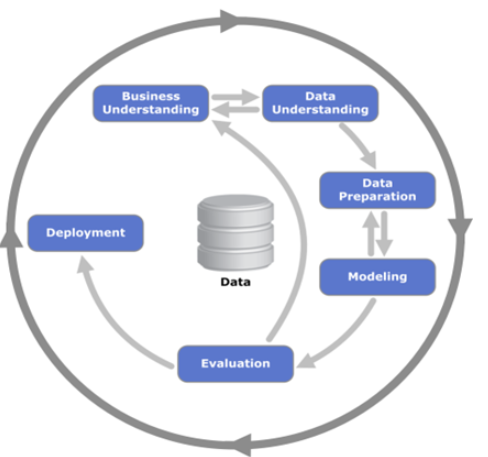

## 2. Librerias 

In [2]:
import numpy as np 
import pyarrow.parquet as pq
import dask.dataframe as dd # Se utiliza este modulo debido para trabajar con archivos grandes.
import os
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.express as px
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, RidgeCV, Lasso, LassoCV
from concurrent.futures import ThreadPoolExecutor
from imblearn.over_sampling import SMOTE # Se utiliza para crear datos sinteticos. Especialmente cuando existen desbalances en los datos.
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.impute import SimpleImputer #Utlizar este modulo para imputar los valores faltantes de las mediciones
from sklearn.impute import KNNImputer #Utlizar este modulo para imputar los valores faltantes de las mediciones.
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,cross_validate
from sklearn.linear_model import LogisticRegression, LinearRegression
import xgboost as xgb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 
from scipy.stats import chi2_contingency,randint,probplot
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
import sklearn.metrics as metrics
from datetime import datetime



## 3. Definición de funciones 

In [3]:
def convertir_columnas_categoricas_0(columna):
    for col in columna:
        if col == "PAQ_A-Season":
            continue
        elif df_cluster_0[col].dtype == 'category':
            moda = df_cluster_0[col].value_counts().idxmax()
            df_cluster_0.loc[:, col] = df_cluster_0[col].fillna(moda)
        else:
            print(f"Revisar la conversión {col}")
            
def convertir_columnas_categoricas_1(columna):
    for col in columna:
        if df_cluster_1[col].dtype == 'category':
            moda = df_cluster_1[col].value_counts().idxmax()
            df_cluster_1.loc[:, col] = df_cluster_1[col].fillna(moda)
        else:
            print(f"Revisar la conversión {col}")
            
def convertir_columnas_categoricas_2(columna):
    for col in columna:
        if df_cluster_2[col].dtype == 'category':
            moda = df_cluster_2[col].value_counts().idxmax()
            df_cluster_2.loc[:, col] = df_cluster_2[col].fillna(moda)
        else:
            print(f"Revisar la conversión {col}")

def convertir_a_categoricas(columna):
    for col in columna:
        df_completo[col]= df_completo[col].astype('category')

            
def convertir_a_categoricas_0(columna):
    for col in columna:
        df_cluster_0[col] = df_cluster_0[col].astype('category')

def convertir_a_categoricas_1(columna):
    for col in columna:
        df_cluster_1[col]= df_cluster_1[col].astype('category')

def convertir_a_categoricas_2(columna):
    for col in columna:
        df_cluster_2[col]= df_cluster_2[col].astype('category')


def reemplazar_atipicos_con_mediana_0(columna):

    for col in columna:
        mediana = df_cluster_0[col].median()
    
        # Calcular los límites usando el rango intercuartílico (IQR)
        Q1 = df_cluster_0[col].quantile(0.25)
        Q3 = df_cluster_0[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        lista = [ dato for dato in df_cluster_0[col] if dato < limite_inferior or dato > limite_superior]
        
        df_cluster_0[col] = df_cluster_0[col].replace(lista,mediana)


def reemplazar_atipicos_con_mediana_1(columna):

    for col in columna:
        mediana = df_cluster_1[col].median()
    
        # Calcular los límites usando el rango intercuartílico (IQR)
        Q1 = df_cluster_1[col].quantile(0.25)
        Q3 = df_cluster_1[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        lista = [ dato for dato in df_cluster_1[col] if dato < limite_inferior or dato > limite_superior]
        
        df_cluster_1[col] = df_cluster_1[col].replace(lista,mediana)       

    
    
def reemplazar_atipicos_con_mediana_2(columna):

    for col in columna:
        mediana = df_cluster_2[col].median()
    
        # Calcular los límites usando el rango intercuartílico (IQR)
        Q1 = df_cluster_2[col].quantile(0.25)
        Q3 = df_cluster_2[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        lista = [ dato for dato in df_cluster_2[col] if dato < limite_inferior or dato > limite_superior]
        
        df_cluster_2[col] = df_cluster_2[col].replace(lista,mediana)

def sustitucion_valores_nulos_num(columna, df):
    for col in columna:
        if df[col].dtype == 'int' or df[col].dtype == 'float':
            mediana = df[col].median()
            df.loc[:, col] = df[col].fillna(mediana)
        else:
            print(f"Revisar la conversión {col}")

def sustitucion_valores_nulos_num_p(columna, df):
    for col in columna:
        if df[col].dtype == 'int' or df[col].dtype == 'float':
            mediana = df[col].median()
            df.loc[:, col] = df[col].fillna(mediana)
        else:
            print(f"Revisar la conversión {col}")

def imputar_con_KNN(columnas, df):
    columnas_a_imputar = columnas
    subconjunto = df[columnas_a_imputar]

    # Aplicar KNNImputer solo a las columnas seleccionadas
    knn_imputer = KNNImputer(n_neighbors=5)
    subconjunto_imputado = pd.DataFrame(knn_imputer.fit_transform(subconjunto), columns= columnas_a_imputar)

    # Reemplazar las columnas imputadas en el DataFrame original
    df[columnas_a_imputar] = subconjunto_imputado

def imputar_con_SI(columnas,df):
    # Definir las columnas a imputar
    columnas_a_imputar_GP = columnas
    
    # Comprobar si las columnas existen en el DataFrame
    columnas_existentes = [col for col in columnas_a_imputar_GP if col in df.columns]
    
    # Seleccionar solo las columnas existentes
    subconjunto_GP = df[columnas_existentes]

    # Imputar valores faltantes usando la media
    simple_imputer = SimpleImputer(strategy='mean')
    subconjunto_imputado_GP = pd.DataFrame(simple_imputer.fit_transform(subconjunto_GP), columns=columnas_existentes, index=df.index)

    # Actualizar las columnas imputadas en el DataFrame original
    df[columnas_existentes] = subconjunto_imputado_GP

    return df

# Esa función se utiliza para crear un histograma de los modelos de clasificación para saber que tan bien clasifica
def represento_doble_hist(x_1, x_0, n_bins=11, title='', label_1='Clase 1', 
                          label_0='Clase 0', density=0, figsize=(4, 3)):
    bins = n_bins
    plt.figure(figsize=figsize)  # Tamaño más pequeño por gráfico
    plt.hist(x_1, bins, density=density, alpha=0.5, label=label_1, color='red')    
    plt.hist(x_0, bins, density=density, alpha=0.5, label=label_0, color='green')
    plt.title(title)
    plt.xlabel('Probabilidad predicha')
    plt.ylabel('Frecuencia relativa' if density else 'Frecuencia')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()
    plt.show() 

# Esta función se utiliza para crear varios graficos histogramas utilizando la estrategia OvR 
def representar_histogramas_ovr(Y_test, y_t_pred_pro, clases=None, n_bins=20, figsize=(4, 3)):
    n_clases = y_t_pred_pro.shape[1]
    if clases is None:
        clases = list(range(n_clases))

    for i in clases:
        y_scores = y_t_pred_pro[:, i]
        x_1 = y_scores[Y_test == i]
        x_0 = y_scores[Y_test != i]

        titulo = f'Distribución de probabilidades - Clase {i} vs Resto'

        represento_doble_hist(x_1, x_0, n_bins=n_bins,
                              title=titulo,
                              label_1=f'Clase {i} (positivos)',
                              label_0='Resto (negativos)',
                              density=1,
                              figsize=figsize)

## 3. Cargando los conjuntos de datos

In [4]:
# Conjunto de datos de Actigrafia

df_series_train = dd.read_parquet('/kaggle/input/child-mind-institute-problematic-internet-use/series_train.parquet')
df_series_test =  dd.read_parquet('/kaggle/input/child-mind-institute-problematic-internet-use/series_test.parquet')


### 3.1 Creando columnas y dando mantenimiento a los datos de a Actigrafia

In [5]:
# Tratamiento para cargar  y hacer el resumen de la columna dias de la semana
conteo_por_grupo = df_series_train.groupby("id")["weekday"].value_counts().compute()

df_result = conteo_por_grupo.reset_index(name='conteo')
valores_mas_frecuentes = df_result.loc[df_result.groupby('id')['conteo'].idxmax()]

valores_mas_frecuentes = valores_mas_frecuentes[["id","weekday"]].drop_duplicates()

df_weekday = valores_mas_frecuentes.dropna()


/usr/local/lib/python3.10/dist-packages/dask_expr/_groupby.py:1554: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  self._meta = self.obj._meta.groupby(


In [6]:
# Tratamiento para cargar y hacer el resumen la columna temporadas del año 

conteo_por_grupo = df_series_train.groupby("id")["quarter"].value_counts().compute()

df_result = conteo_por_grupo.reset_index(name='conteo')
valores_mas_frecuentes = df_result.loc[df_result.groupby('id')['conteo'].idxmax()]

valores_mas_frecuentes = valores_mas_frecuentes[["id","quarter"]].drop_duplicates()

df_quarter = valores_mas_frecuentes.dropna()

In [7]:
# Conteo de la cantidad de filas del conjunto de datos

cantidad_filas = df_series_train.shape[0].compute()
print(f"Cantidad de filas: {cantidad_filas}")

Cantidad de filas: 314569149


In [8]:
#df_series_train_1 = df_series_train.map_partitions(len).compute()
#print(df_series_train_1)

In [9]:
# Trasformando las columnas weekday y quater en categoricas

df_weekday['weekday'] = df_weekday["weekday"].astype('category')
df_quarter['quarter'] = df_quarter["quarter"].astype('category')

### 3.2 Creando Resumen de la tabla series_train

In [10]:
# Realizando un resumen de la data series_train debido a que es muy pesada, tiene mas de 314 millones de registros

resumen = df_series_train.groupby('id').agg({
    'X': 'mean',                                   
    'Y': 'mean',                                   
    'Z': 'mean',                                   
    'enmo': 'mean',                                 
    'light': 'mean',                     
    'battery_voltage': 'mean',
    'time_of_day': 'mean',
    'relative_date_PCIAT': 'mean'
})

In [11]:
print(resumen.compute())

                 X         Y         Z      enmo       light  battery_voltage  \
id                                                                              
0417c91e -0.147090 -0.017002 -0.004732  0.058441  123.444945      3922.278551   
1c063ebc  0.400091 -0.069567 -0.035199  0.044230   89.860481      3848.648695   
2cda86bd  0.027417 -0.384444 -0.278186  0.005275    3.562555      3839.013173   
350cf38b -0.241119 -0.001396 -0.188692  0.048448   21.641680      3905.451498   
64ed48c4 -0.009472 -0.028348 -0.964124  0.000434    9.016723      3825.847369   
...            ...       ...       ...       ...         ...              ...   
fe9c71d8       NaN       NaN       NaN       NaN         NaN              NaN   
fecc07d6       NaN       NaN       NaN       NaN         NaN              NaN   
ff18b749       NaN       NaN       NaN       NaN         NaN              NaN   
ffcd4dbd       NaN       NaN       NaN       NaN         NaN              NaN   
ffed1dd5       NaN       NaN

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


### 3.3 Revisión y Limpieza del resumen de la tabla series_train

In [12]:
# Revisando los valores faltantes del resumen
valores_faltantes_por_columna = resumen.isna().sum().compute()
print(valores_faltantes_por_columna)

X                      60758
Y                      60758
Z                      60758
enmo                   60758
light                  60758
battery_voltage        60758
time_of_day            60758
relative_date_PCIAT    60758
dtype: int64


In [13]:
# Eliminando los valores faltantes generados por el  resumen
resumen_limpio = resumen.dropna()


In [14]:
# Eliminando los valores duplicados de la tabla resumen
resumen_limpio = resumen_limpio.drop_duplicates()

In [15]:
# Reseteo de los indices debido al mantenimiento previo
resumen_limpio = resumen_limpio.reset_index()

resumen_limpio = resumen_limpio.compute()

In [16]:
# Uniendo las columnas weekday y quarter 
df_union_c = pd.merge(df_weekday,df_quarter, on='id', how='inner')

In [17]:
# Revisando la unión
df_union_c.describe()

,id,weekday,quarter
count,996,996,996
unique,996,7,4
top,00115b9f,5,1
freq,1,192,326


In [18]:
# Unidendo los la tabla resumen luego de su tratamiento y la tabla unión de las columnas weekday y quarter
df_union_series = pd.merge(resumen_limpio,df_union_c, on='id',how='left')

In [19]:
# Revisando la unión
df_union_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   994 non-null    category
 1   X                    994 non-null    float64 
 2   Y                    994 non-null    float64 
 3   Z                    994 non-null    float64 
 4   enmo                 994 non-null    float64 
 5   light                994 non-null    float64 
 6   battery_voltage      994 non-null    float64 
 7   time_of_day          994 non-null    float64 
 8   relative_date_PCIAT  994 non-null    float64 
 9   weekday              994 non-null    category
 10  quarter              994 non-null    category
dtypes: category(3), float64(8)
memory usage: 106.5 KB


In [20]:
# Cargando los datos tabulares sobre las mediciones con intruementos.
test = pd.read_csv("/kaggle/input/child-mind-institute-problematic-internet-use/test.csv")
train = pd.read_csv("/kaggle/input/child-mind-institute-problematic-internet-use/train.csv")

In [21]:
# Revisado las primeras 5 filas
train.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
#Revisando si tiene valores duplicados 
train.duplicated().sum()

0

In [23]:
# Uniendo los conjuntos de datos train y df_union_series 

df_completo = pd.merge(train,df_union_series, on='id',how='left')

## Analisis Exploratorio 

In [24]:
# Revisando las primeras 5 filas 

df_completo.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,X,Y,Z,enmo,light,battery_voltage,time_of_day,relative_date_PCIAT,weekday,quarter
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,000fd460,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00105258,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,-0.316384,0.016009,-0.16789,0.047388,42.29631,4053.578768,5.046215e+13,53.201685,5,3
4,0016bb22,Spring,18,1,Summer,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
#Revisando las dimensiones del conjunto de datos
df_completo.shape

(3960, 92)

In [26]:
# Revisando los tipos de datos y valores nulos del conjunto de datos

df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 92 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      3960 non-null   object  
 1   Basic_Demos-Enroll_Season               3960 non-null   object  
 2   Basic_Demos-Age                         3960 non-null   int64   
 3   Basic_Demos-Sex                         3960 non-null   int64   
 4   CGAS-Season                             2555 non-null   object  
 5   CGAS-CGAS_Score                         2421 non-null   float64 
 6   Physical-Season                         3310 non-null   object  
 7   Physical-BMI                            3022 non-null   float64 
 8   Physical-Height                         3027 non-null   float64 
 9   Physical-Weight                         3076 non-null   float64 
 10  Physical-Waist_Circumference            898 non-

In [27]:
columnas_categoricas = ['Basic_Demos-Sex','FGC-FGC_CU_Zone','FGC-FGC_GSND_Zone','FGC-FGC_GSD_Zone','FGC-FGC_PU_Zone','FGC-FGC_SRL_Zone','FGC-FGC_SRR_Zone',
                     'FGC-FGC_TL_Zone','BIA-BIA_Activity_Level_num','BIA-BIA_Frame_num','PCIAT-PCIAT_01','PCIAT-PCIAT_02','PCIAT-PCIAT_03','PCIAT-PCIAT_04',
                     'PCIAT-PCIAT_05','PCIAT-PCIAT_06','PCIAT-PCIAT_07','PCIAT-PCIAT_08','PCIAT-PCIAT_09','PCIAT-PCIAT_10','PCIAT-PCIAT_11',
                     'PCIAT-PCIAT_12','PCIAT-PCIAT_13','PCIAT-PCIAT_14','PCIAT-PCIAT_15','PCIAT-PCIAT_16','PCIAT-PCIAT_17','PCIAT-PCIAT_18',
                     'PCIAT-PCIAT_19','PCIAT-PCIAT_20','PreInt_EduHx-computerinternet_hoursday','quarter','weekday']

In [28]:
columnas_str = ['Basic_Demos-Enroll_Season','CGAS-Season','Physical-Season','Fitness_Endurance-Season'
                ,'FGC-Season','BIA-Season','PAQ_A-Season','PAQ_C-Season','PCIAT-Season','SDS-Season','PreInt_EduHx-Season']

In [29]:
# Transformando algunas columnas a categoricas
convertir_a_categoricas(columnas_categoricas)

In [30]:
# Revisando los cambios
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 92 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      3960 non-null   object  
 1   Basic_Demos-Enroll_Season               3960 non-null   object  
 2   Basic_Demos-Age                         3960 non-null   int64   
 3   Basic_Demos-Sex                         3960 non-null   category
 4   CGAS-Season                             2555 non-null   object  
 5   CGAS-CGAS_Score                         2421 non-null   float64 
 6   Physical-Season                         3310 non-null   object  
 7   Physical-BMI                            3022 non-null   float64 
 8   Physical-Height                         3027 non-null   float64 
 9   Physical-Weight                         3076 non-null   float64 
 10  Physical-Waist_Circumference            898 non-

## Analizando las distribuciones y valores outliers de algunas variables

In [31]:
fig = px.histogram(df_completo, x =  "Physical-Height", title = "Distriucion de Physical-Height" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [32]:
fig = px.box(df_completo, x =  "Physical-Height", title = "Valores outliers Physical-Height")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [33]:
fig = px.histogram(df_completo, x =  "PreInt_EduHx-computerinternet_hoursday", title = "Distriucion de PreInt_EduHx-computerinternet_hoursday" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [34]:
fig = px.histogram(df_completo, x =  "Physical-BMI", title = "Distriucion de Physical-BMI" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [35]:
fig = px.box(df_completo, x =  "Physical-BMI", title = "Valores outliers Physical-BMI")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [36]:
fig = px.histogram(df_completo, x =  "Physical-HeartRate", title = "Distriucion de Physical-HeartRate" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [37]:
fig = px.box(df_completo, x =  "Physical-HeartRate", title = "Valores outliers Physical-HeartRate")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [38]:
fig = px.histogram(df_completo, x =  "Physical-Systolic_BP", title = "Distriucion de Physical-Systolic_BP" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [39]:
fig = px.box(df_completo, x =  "Physical-Systolic_BP", title = "Valores outliers Physical-Systolic_BP")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [40]:
fig = px.histogram(df_completo, x =  "Fitness_Endurance-Time_Mins", title = "Distriucion de Fitness_Endurance-Time_Mins" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [41]:
fig = px.histogram(df_completo, x =  "SDS-SDS_Total_Raw", title = "Distriucion de SDS-SDS_Total_Raw" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [42]:
fig = px.box(df_completo, x =  "SDS-SDS_Total_Raw", title = "Valores outliers SDS-SDS_Total_Raw")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

## Realizando cluster para trabajar con los valores outliers y valores nulos

In [43]:
df_completo["Basic_Demos-Sex"].astype(int)

0       0
1       0
2       1
3       0
4       1
       ..
3955    0
3956    0
3957    0
3958    0
3959    0
Name: Basic_Demos-Sex, Length: 3960, dtype: int64

In [44]:
scaler = StandardScaler()
X_C = scaler.fit_transform(df_completo[['Basic_Demos-Age','Basic_Demos-Sex']])

In [45]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init ='random', random_state=0)
    kmeans.fit(X_C)
    inertia.append(kmeans.inertia_)

In [46]:
# Graficar el gráfico del codo con plotly
fig = px.line(x=range(1, 11), y=inertia, markers=True, title='Método del Codo')
fig.update_layout(xaxis_title='Número de Clústeres', yaxis_title='Inercia')
fig.show()

In [47]:
kmeans = KMeans(n_clusters=3, init ='random', random_state=0)
clusters =  kmeans.fit_predict(X_C)

In [48]:
clusters

array([0, 0, 2, ..., 0, 1, 0], dtype=int32)

In [49]:
df_completo['Clusters'] = clusters 

In [50]:
df_completo['Clusters'].value_counts()

Clusters
0    1689
2    1432
1     839
Name: count, dtype: int64

In [51]:
df_cluster_0 = df_completo[df_completo['Clusters']== 0].copy()
df_cluster_1 = df_completo[df_completo['Clusters']== 1].copy()
df_cluster_2 = df_completo[df_completo['Clusters']== 2].copy()

In [52]:
df_cluster_2 .info()

<class 'pandas.core.frame.DataFrame'>
Index: 1432 entries, 2 to 3954
Data columns (total 93 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      1432 non-null   object  
 1   Basic_Demos-Enroll_Season               1432 non-null   object  
 2   Basic_Demos-Age                         1432 non-null   int64   
 3   Basic_Demos-Sex                         1432 non-null   category
 4   CGAS-Season                             906 non-null    object  
 5   CGAS-CGAS_Score                         852 non-null    float64 
 6   Physical-Season                         1184 non-null   object  
 7   Physical-BMI                            1073 non-null   float64 
 8   Physical-Height                         1076 non-null   float64 
 9   Physical-Weight                         1091 non-null   float64 
 10  Physical-Waist_Circumference            342 non-null 

In [53]:
convertir_columnas_categoricas_0(columnas_categoricas)

In [54]:
convertir_columnas_categoricas_1(columnas_categoricas)

In [55]:
convertir_columnas_categoricas_2(columnas_categoricas)

In [56]:
convertir_a_categoricas_0(columnas_str)

In [57]:
convertir_a_categoricas_1(columnas_str)

In [58]:
convertir_a_categoricas_2(columnas_str)

In [59]:
convertir_columnas_categoricas_1(columnas_str)

In [60]:
convertir_columnas_categoricas_2(columnas_str)

In [61]:
convertir_columnas_categoricas_0(columnas_str)

In [62]:
columnas_numericas = ["CGAS-CGAS_Score","Physical-BMI","Physical-Height","Physical-Weight","Physical-Waist_Circumference","Physical-Diastolic_BP","Physical-HeartRate"
                         ,"Physical-Systolic_BP","Fitness_Endurance-Max_Stage","Fitness_Endurance-Time_Mins","Fitness_Endurance-Time_Sec","FGC-FGC_CU","FGC-FGC_GSND"
                         ,"FGC-FGC_GSD","FGC-FGC_PU","FGC-FGC_SRL","FGC-FGC_SRR","FGC-FGC_TL","BIA-BIA_BMC","BIA-BIA_BMI","BIA-BIA_BMR","BIA-BIA_DEE","BIA-BIA_ECW"
                         ,"BIA-BIA_FFM","BIA-BIA_FFMI","BIA-BIA_FMI","BIA-BIA_Fat","BIA-BIA_ICW","BIA-BIA_LDM","BIA-BIA_LST","BIA-BIA_SMM","BIA-BIA_TBW","PAQ_A-PAQ_A_Total"
                         ,"PAQ_C-PAQ_C_Total","PCIAT-PCIAT_Total","SDS-SDS_Total_Raw","SDS-SDS_Total_T"]
                    


In [63]:
reemplazar_atipicos_con_mediana_0(columnas_numericas)

In [64]:
reemplazar_atipicos_con_mediana_1(columnas_numericas)

In [65]:
reemplazar_atipicos_con_mediana_2(columnas_numericas)

In [66]:
sustitucion_valores_nulos_num_p(columnas_numericas,df_cluster_0)

In [67]:
sustitucion_valores_nulos_num_p(columnas_numericas,df_cluster_1)

In [68]:
sustitucion_valores_nulos_num_p(columnas_numericas,df_cluster_2)

In [69]:
df_cluster_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1689 entries, 0 to 3959
Data columns (total 93 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      1689 non-null   object  
 1   Basic_Demos-Enroll_Season               1689 non-null   category
 2   Basic_Demos-Age                         1689 non-null   int64   
 3   Basic_Demos-Sex                         1689 non-null   category
 4   CGAS-Season                             1689 non-null   category
 5   CGAS-CGAS_Score                         1689 non-null   float64 
 6   Physical-Season                         1689 non-null   category
 7   Physical-BMI                            1689 non-null   float64 
 8   Physical-Height                         1689 non-null   float64 
 9   Physical-Weight                         1689 non-null   float64 
 10  Physical-Waist_Circumference            1689 non-null

In [70]:
def nueva_columna(df):
    df["Participo_Prueba"] = ["Si" if dato is not None and not pd.isna(dato) else "No" for dato in df["X"]]
    df["Participo_Prueba"] = df["Participo_Prueba"].astype("category")

In [71]:
# Creando la columna participo prueba para poder diferenciar los participantes 
nueva_columna(df_cluster_0)
nueva_columna(df_cluster_1)
nueva_columna(df_cluster_2)

In [72]:
df_cluster_0["Participo_Prueba"].value_counts()
df_cluster_1["Participo_Prueba"].value_counts()
df_cluster_2["Participo_Prueba"].value_counts()

Participo_Prueba
No    1094
Si     338
Name: count, dtype: int64

In [73]:
df_cluster_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 8 to 3958
Data columns (total 94 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      839 non-null    object  
 1   Basic_Demos-Enroll_Season               839 non-null    category
 2   Basic_Demos-Age                         839 non-null    int64   
 3   Basic_Demos-Sex                         839 non-null    category
 4   CGAS-Season                             839 non-null    category
 5   CGAS-CGAS_Score                         839 non-null    float64 
 6   Physical-Season                         839 non-null    category
 7   Physical-BMI                            839 non-null    float64 
 8   Physical-Height                         839 non-null    float64 
 9   Physical-Weight                         839 non-null    float64 
 10  Physical-Waist_Circumference            839 non-null  

In [74]:
columnas_a_imputar = ["sii","X","Y","Z","enmo","light","battery_voltage","time_of_day","relative_date_PCIAT"]



In [75]:
imputar_con_KNN(columnas_a_imputar , df_cluster_0)
imputar_con_KNN(columnas_a_imputar , df_cluster_1)
imputar_con_KNN(columnas_a_imputar , df_cluster_2)

In [76]:
df_cluster_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 8 to 3958
Data columns (total 94 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      839 non-null    object  
 1   Basic_Demos-Enroll_Season               839 non-null    category
 2   Basic_Demos-Age                         839 non-null    int64   
 3   Basic_Demos-Sex                         839 non-null    category
 4   CGAS-Season                             839 non-null    category
 5   CGAS-CGAS_Score                         839 non-null    float64 
 6   Physical-Season                         839 non-null    category
 7   Physical-BMI                            839 non-null    float64 
 8   Physical-Height                         839 non-null    float64 
 9   Physical-Weight                         839 non-null    float64 
 10  Physical-Waist_Circumference            839 non-null  

In [77]:
df_cluster_0 = imputar_con_SI(columnas_a_imputar,df_cluster_0)
df_cluster_1 = imputar_con_SI(columnas_a_imputar,df_cluster_1)
df_cluster_2 = imputar_con_SI(columnas_a_imputar,df_cluster_2)

In [78]:
df_cluster_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1432 entries, 2 to 3954
Data columns (total 94 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   id                                      1432 non-null   object  
 1   Basic_Demos-Enroll_Season               1432 non-null   category
 2   Basic_Demos-Age                         1432 non-null   int64   
 3   Basic_Demos-Sex                         1432 non-null   category
 4   CGAS-Season                             1432 non-null   category
 5   CGAS-CGAS_Score                         1432 non-null   float64 
 6   Physical-Season                         1432 non-null   category
 7   Physical-BMI                            1432 non-null   float64 
 8   Physical-Height                         1432 non-null   float64 
 9   Physical-Weight                         1432 non-null   float64 
 10  Physical-Waist_Circumference            1432 non-null

In [79]:
fig = px.histogram(df_cluster_0, x =  "time_of_day", title = "Distriucion de Fitness_Endurance-Time_Mins" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [80]:
print(df_cluster_0.shape)
print(df_cluster_1.shape)
print(df_cluster_2.shape)

(1689, 94)
(839, 94)
(1432, 94)


In [81]:
df = pd.concat([df_cluster_0,df_cluster_1,df_cluster_2], ignore_index = True)

In [82]:
df.duplicated().sum()

0

In [83]:
df.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,Z,enmo,light,battery_voltage,time_of_day,relative_date_PCIAT,weekday,quarter,Clusters,Participo_Prueba
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,0.014190,0.02774,36.503995,3848.867383,5.571138e+12,58.302728,5,1,0,No
1,000fd460,Summer,9,0,Spring,65.0,Fall,14.035590,48.0,46.0,...,0.014190,0.02774,36.503995,3848.867383,5.571138e+12,58.302728,5,1,0,No
2,00115b9f,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,0.014190,0.02774,36.503995,3848.867383,5.571138e+12,58.302728,5,3,0,Si
3,0038ba98,Fall,10,0,Spring,65.0,Fall,19.660760,55.0,84.6,...,0.014190,0.02774,36.503995,3848.867383,5.571138e+12,58.302728,5,1,0,No
4,00abe655,Fall,11,0,Summer,66.0,Spring,16.871582,52.0,64.6,...,-0.128379,0.04656,44.981426,3880.435710,3.607885e+12,59.438255,5,1,0,No


In [84]:
df.shape

(3960, 94)

### Análisis Univariante

In [85]:
fig = px.histogram(df, x = "PreInt_EduHx-computerinternet_hoursday", title = "Distriucion de PreInt_EduHx-computerinternet_hoursday")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Como podemos observar de acuerdo con los datos:
#### 51% de los participantes duran menos de una hora usando internet al dia 
#### 10% de los participantes duran una hora usando internet al dia 
#### 29% de los participantes duran dos horas usando internet por dia 
####  9% de los participantes duran mas de tres horas al dia usando el internet

#### De acuerdo con estudios se argumento que aquellas personas que pasan entre 8.5 horas a 21.5 por semana se considera uso problematico. Basando en esto se podria decir 
#### que el 38% de los participantes pueden tener uso problematico del internet.

In [86]:
fig = px.histogram(df, x = "Basic_Demos-Age", title = "Distriucion de  Basic_Demos-Age" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Aqui se puede observar que el 64% de los participantes estan en la edad de la niñez y el 29% en la adolecencia

In [87]:
fig = px.histogram(df, x = "Basic_Demos-Sex", title = "Distriucion de Basic_Demos-Sex" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### En este grafico vemos que el 63% de los participantes son de sexo masculino y el 37% femenino.
#### En estudios previos se ha observado que las mujeres tienen a tener una mayor propension al uso excesivo del internet.

In [88]:
fig = px.histogram(df, x = "Physical-Season", title = "Distriucion de Physical-Season" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

####  Vemos que el 40% de los participantes realizan las actividades fisicas en privaera. 

In [89]:
fig = px.histogram(df, x = "Physical-HeartRate", title = "Distriucion de Physical-HeartRate" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [90]:
df\
.groupby(["Basic_Demos-Sex"], as_index = False)\
.agg(promedio_latido = ("Physical-HeartRate","mean"),
    maximo_latidos = ("Physical-HeartRate","max"))
           


,Basic_Demos-Sex,promedio_latido,maximo_latidos
0,0,80.856683,119.0
1,1,81.930894,118.0


#### En cuadro y grafico podemos observar el promedio de latidos del corazon por minutos esta dentro del rango normal tanto del sexo masculino como femenino.

In [91]:
fig = px.histogram(df, x = "PCIAT-PCIAT_Total", title = "Distriucion de PCIAT-PCIAT_Total" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [92]:
print("Cantidad de participante con Nivel de uso severo:", len(df[df["PCIAT-PCIAT_Total"] >= 80]))
print("Cantidad de participante con Nivel de uso moderado:", len(df[(df["PCIAT-PCIAT_Total"] >= 50) & (df["PCIAT-PCIAT_Total"] <= 79)]))
print("Cantidad de participante con Nivel de uso leve:", len(df[(df["PCIAT-PCIAT_Total"] >= 31) & (df["PCIAT-PCIAT_Total"] <= 49)]))
print("Cantidad de participante con Nivel de uso adecuado:", len(df[(df["PCIAT-PCIAT_Total"] >= 0) & (df["PCIAT-PCIAT_Total"] <= 30)]))

Cantidad de participante con Nivel de uso severo: 25
Cantidad de participante con Nivel de uso moderado: 374
Cantidad de participante con Nivel de uso leve: 1022
Cantidad de participante con Nivel de uso adecuado: 2539


#### 1% tiene un nivel de uso del internet severo.
#### 10% tiene un nivel de uso moderado del internet
#### 26% tiene un nivel de uso leve del internet.
#### 64% tiene un nivel de uso dentro de lo normal.

In [93]:
fig = px.histogram(df, x = "Physical-BMI", title = "Distriucion de Physical-BMI")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [94]:
print("Cantidad de participante con insuficiencia de peso:", len(df[df["Physical-BMI"] < 18.5]))
print("Cantidad de participante con peso normal:", len(df[(df["Physical-BMI"] >= 18.5) & (df["Physical-BMI"] <= 24.9)]))
print("Cantidad de participante con sobrepeso:", len(df[(df["Physical-BMI"] >= 25) & (df["Physical-BMI"] <= 30)]))
print("Cantidad de participante con obesidad:", len(df[df["Physical-BMI"] > 30]))

Cantidad de participante con insuficiencia de peso: 2511
Cantidad de participante con peso normal: 1219
Cantidad de participante con sobrepeso: 186
Cantidad de participante con obesidad: 35


#### Cantidad de participante con insuficiencia de peso 63%.
#### Cantidad de participante con peso normal 31%
#### Cantidad de participante con sobrepeso 5%
#### Cantidad de participante con obesidad 1%

In [95]:
fig = px.histogram(df, x = "PCIAT-PCIAT_06", title = "Distriucion de PCIAT-PCIAT_06")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Esta columna nos informa con que frecuencia  las calificaciones de los participantes se vio afectado por el uso del internet
#### EL 53% de los participantes dicen que sus calificaciones se ven afectadas. 
#### El 29% de los participantes dicen que raras las veces sus calificacion se ven afectadoas 
#### El 9% de los participantes dicen que ocasionalmente
#### EL 4%  de los participantes dicen que Frecuentemente 
#### El 3% de los participantes dicen que a menudo 
#### EL 2% de los participantes dicen que siempre

In [96]:
fig = px.histogram(df, x = "PCIAT-PCIAT_20", title = "Distriucion de PCIAT-PCIAT_20")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### ¿Con qué frecuencia su hijo se siente deprimido, de mal humor o nervioso cuando no está conectado y eso parece desaparecer cuando vuelve a conectarse?
#### EL 55% de los participantes dicen que no se ven afectadas. 
#### El 29% de los participantes dicen que raras veces.
#### El 9% de los participantes dicen que ocasionalmente
#### EL 3%  de los participantes dicen que Frecuentemente 
#### El 3% de los participantes dicen que a menudo 
#### EL 1% de los participantes dicen que siempre

In [97]:
fig = px.histogram(df, x = "PAQ_A-PAQ_A_Total", title = "Distriucion de PAQ_A-PAQ_A_Total")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [98]:
print("Cantidad de participante adolecentes bajo nivel de actividad fisica:", len(df[(df["PAQ_A-PAQ_A_Total"] >= 1) & (df["PAQ_A-PAQ_A_Total"] <= 1.9)]))
print("Cantidad de participante adolecentes nivel moderado de actividad fisica:", len(df[(df["PAQ_A-PAQ_A_Total"] >= 2) & (df["PAQ_A-PAQ_A_Total"] <= 2.9 )]))
print("Cantidad de participante adolecentes alto nivel de actividad fisica:", len(df[df["PAQ_A-PAQ_A_Total"] > 3]))

Cantidad de participante adolecentes bajo nivel de actividad fisica: 1436
Cantidad de participante adolecentes nivel moderado de actividad fisica: 703
Cantidad de participante adolecentes alto nivel de actividad fisica: 91


#### Esta metrica, PAQ_A-PAQ_A_Total, nos permite saber los niveles de actividades de los adolecentes la cual esta muy relacionado con algunos aspecto de la salud. Sabemos a traves de estudios y comentarios de expertos que a mayor nivel de actividad se puede tener mejor sistema cardiovascular, mayor fuerza muscular, mejor riesgo de obesidad. Adicional a esto tambien puede tener menor niveles de estres, ansiedad y depresión.


#### El 64% de los adolecentes tuvienron un nivel de activad fisica baja
#### El 31% de los adolecentes tuvieorn  un nivel de actividad fisica modera
#### El  6% de los adolecentes tuvieron un nivel de actividad fisica alta  

In [99]:
fig = px.histogram(df, x = "PAQ_C-PAQ_C_Total", title = "Distriucion de PAQ_C-PAQ_C_Total")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [100]:
print("Cantidad de participante adolecentes bajo nivel de actividad fisica:", len(df[(df["PAQ_C-PAQ_C_Total"] >= 1) & (df["PAQ_C-PAQ_C_Total"] <= 1.9)]))
print("Cantidad de participante adolecentes nivel moderado de actividad fisica:", len(df[(df["PAQ_C-PAQ_C_Total"] >= 2) & (df["PAQ_C-PAQ_C_Total"] <= 2.9 )]))
print("Cantidad de participante adolecentes alto nivel de actividad fisica:", len(df[df["PAQ_C-PAQ_C_Total"] > 3]))

Cantidad de participante adolecentes bajo nivel de actividad fisica: 353
Cantidad de participante adolecentes nivel moderado de actividad fisica: 2958
Cantidad de participante adolecentes alto nivel de actividad fisica: 527


#### Esta metrica, PAQ_C-PAQ_C_Total, nos permite saber los niveles de actividades de los niños la cual esta muy relacionado con algunos aspecto de la salud. Sabemos a traves de estudios y comentarios de expertos que a mayor nivel de actividad se puede tener mejor sistema cardiovascular, mayor fuerza muscular, mejor riesgo de obesidad. Adicional a esto tambien puede tener menor niveles de estres, ansiedad y depresión.


#### El  9% de los adolecentes tuvienron un nivel de activad fisica baja
#### El 75% de los adolecentes tuvieorn  un nivel de actividad fisica moderada
#### El 16% de los adolecentes tuvieron un nivel de actividad fisica alta 

In [101]:
fig = px.histogram(df, x = "FGC-FGC_TL_Zone", title = "Distriucion de FGC-FGC_TL_Zone")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Esta metrica esta relacionado o hace referencia a la fuerza del tronco de los ninos o y adolecentes. Aquellos participantes que tengan un nivel de fuerza mas considerable se puede relacionar con un nivel mayor de actividad fisica y por ende menor sedentarimos por lo tanto menos riesgo de usas de manera problematica el internet.

#### El 88% de los participantes tiene una fuerza del tronco adecuada, lo que podria sugeriar unos niveles altos de actividad fisica.
#### El 12% de los participantes tienen menos fuerza en el tronco, lo que podria sugerir una baja o inadecuada actividad fisica.

In [102]:
fig = px.histogram(df, x = "SDS-SDS_Total_Raw", title = "Distriucion de SDS-SDS_Total_Raw")


fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [103]:
print("Cantidad de participante sin pertubarciones en el sueño :", len(df[df["SDS-SDS_Total_Raw"] <= 29]))
print("Cantidad de participante con pocas pertubaciones en el de sueños,normales :", len(df[(df["SDS-SDS_Total_Raw"] >= 30) & (df["SDS-SDS_Total_Raw"] <= 50)]))
print("Cantidad de participante con moderada perturnaciones de sueños:", len(df[(df["SDS-SDS_Total_Raw"] > 50) & (df["SDS-SDS_Total_Raw"] <= 55 )]))
print("Cantidad de participante con trastornos significativos de sueños:", len(df[(df["SDS-SDS_Total_Raw"] > 55) & (df["SDS-SDS_Total_Raw"] <= 60 )]))
print("Cantidad de participante con graves tratosnos de sueños:", len(df[df["SDS-SDS_Total_Raw"] > 60]))

Cantidad de participante sin pertubarciones en el sueño : 232
Cantidad de participante con pocas pertubaciones en el de sueños,normales : 3358
Cantidad de participante con moderada perturnaciones de sueños: 182
Cantidad de participante con trastornos significativos de sueños: 115
Cantidad de participante con graves tratosnos de sueños: 73


#### De acuerdo con estos datos, el 85% tiene un patron de sueño normal, 5% tiene perturbaciones moderadas, 3% tratornos significativos de sueños y el 2% restantes graves trastornos.
#### Se podria decir que el 5% de los participantes podria requerir atencion medica debido a sus trastornos. 

In [104]:
fig = px.histogram(df, x = "Physical-Diastolic_BP", title = "Distriucion de Physical-Diastolic_BP" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [105]:
print("Cantidad de participante tienen la presión diastólica muy baja :", len(df[df["Physical-Diastolic_BP"] < 60]))
print("Cantidad de participante tienen la presión diastólica normal :", len(df[(df["Physical-Diastolic_BP"] >= 60) & (df["Physical-Diastolic_BP"] <= 80)]))
print("Cantidad de participante tienen la presión diastólica alta :", len(df[df["Physical-Diastolic_BP"] > 80]))


Cantidad de participante tienen la presión diastólica muy baja : 550
Cantidad de participante tienen la presión diastólica normal : 3064
Cantidad de participante tienen la presión diastólica alta : 346


#### De acuerdo con este grafico el 14% de los particpantes tiene la presión arterial diastólica muy baja esto se puede debe a desidratación, reacciones alergicas, infecciones entre otras caussas.
#### El 77% de los participantes tienen su presión arterial diastólica normal.
#### El  9% restantes tienen un presión arterial diastólica alta, esto se puede deber a inactividad, falta de sueño, sobrepeso entre otros factores.

In [106]:
fig = px.histogram(df, x = "Physical-Systolic_BP", title = "Distriucion de Physical-Systolic_BP" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [107]:
print("Cantidad de participante tienen la presión sistólica muy baja :",len(df[df["Physical-Systolic_BP"] < 90]))
print("Cantidad de participante tienen la presión sistólica normal :",len(df[(df["Physical-Systolic_BP"] >= 90) & (df["Physical-Systolic_BP"] <= 120)]))
print("Cantidad de participante tienen la presión sistólica elevada :",len(df[(df["Physical-Systolic_BP"] > 120) & (df["Physical-Systolic_BP"] <= 129)]))
print("Cantidad de participante estan en etapa de hipertesión :",len(df[df["Physical-Systolic_BP"] > 130]))

Cantidad de participante tienen la presión sistólica muy baja : 39
Cantidad de participante tienen la presión sistólica normal : 2796
Cantidad de participante tienen la presión sistólica elevada : 720
Cantidad de participante estan en etapa de hipertesión : 373


#### De acuerdo con estos datos el 71% de los participantes tienen la presión arterial sistólica normal. 
#### 1% la tiene muy baja. 
#### 18% la tiene elevada.
#### 10% esta en etapa de hipertensión.
#### Estos resultados se deben de considerar los niveles de actividad que estaban realizando.

In [108]:
# Estoy creando una nueva cloumna tipo object para utilizarla en el análisis bivariante.
def clasificar(valor):
    if 0.0 <= valor <= 30.0:
        return "Ninguna"
    elif 31.0 <= valor <= 49.0:
        return "leve"
    elif 50.0 <= valor <= 79.0:
        return "moderada"
    else:
        return "severo"

df["sii_m"] = df["PCIAT-PCIAT_Total"].apply(clasificar)

In [109]:
# Revisando las distribucion de los resutlados
df["sii_m"].value_counts()

sii_m
Ninguna     2539
leve        1022
moderada     374
severo        25
Name: count, dtype: int64

In [110]:
# Estas columnas que reprentan la aceleración, se deben de elevar al cuadrado y srealizar una suma con ellas para poder analizarlas
df['Magnitud'] = np.sqrt(df['X']**2 + df['Y']**2 + df['Z']**2)

In [111]:
fig = px.histogram(df, x = "Magnitud", title = "Distriucion de Magnitud" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [112]:
def clasificar_actividad(valor):
    if 0.0 <= valor <= 0.150:
        return "Reposo"
    elif 0.151 <= valor <= 1:
        return "Caminar"
    else:
        return "Correr"

df["tipo_actividad"] = df["Magnitud"].apply(clasificar_actividad)

In [113]:
df["tipo_actividad"].value_counts()

tipo_actividad
Caminar    2411
Reposo     1546
Correr        3
Name: count, dtype: int64

In [114]:
fig = px.histogram(df, x = "enmo", title = "Distriucion de enmo" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [115]:
# Estoy creando una columna estado movimiento para saber si los participantes estan activo o inactivos

def clasificar_estado(valor):
    if 0.0 <= valor < 0.01:
        return "inactivo"
    if 0.01 <= valor <= 0.04:
        return "baja actividad"
    else:
        return "actividad moderada" 

df["Estado_movimiento"] = df["enmo"].apply(clasificar_estado)

In [116]:
# Revisando la distribución de los resultados
df["Estado_movimiento"].value_counts()

Estado_movimiento
baja actividad        3567
actividad moderada     354
inactivo                39
Name: count, dtype: int64

In [117]:
# Se esta tratando a columna time_of_day para poder calcuar los periodos de actividad mañana, tarde o noche.
df['time_of_day'] = pd.to_datetime(df['time_of_day'],unit = 'ns')
fecha_actual = datetime.now()
epoch_date = datetime(1970, 1, 1)
df['time_of_day'] = df['time_of_day'] + (fecha_actual - epoch_date)

In [118]:
# Luego de tratar la columna esoty creando la columna hororio.
def clasificar_horario(hora):
    hora_dt = pd.to_datetime(hora, format='%H:%M:%S.%f').time()
    if hora_dt >= pd.to_datetime('06:00:00').time() and hora_dt < pd.to_datetime('12:00:00').time():
        return 'Mañana'
    elif hora_dt >= pd.to_datetime('12:00:00').time() and hora_dt < pd.to_datetime('18:00:00').time():
        return 'Tarde'
    else:
        return 'Noche'

df['Horario'] = df['time_of_day'].apply(clasificar_horario)

In [119]:
# Revision de la distribución de los valores de la columna horario.
df['Horario'].value_counts()

Horario
Noche     3598
Tarde      290
Mañana      72
Name: count, dtype: int64

In [120]:
fig = px.histogram(df, x = "Horario", title = "Distriucion de Horario")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [121]:
df["Horario"].value_counts()

Horario
Noche     3598
Tarde      290
Mañana      72
Name: count, dtype: int64

#### Aqui podemos ver que en el horario de la tarde es donde mas registraron actividad, como era de esperarse.
#### El 79% de las actividades se realizan en la tarde, 20% en la noche y 1% en la mañana. Esto se puede deber a que en ese horario esten aun durmiendo. 

### Análisis Multivariante

In [122]:
fig = px.histogram(df, x = "sii_m", title = "Distriucion de sii_m por Basic_Demos-Sex", color = "Basic_Demos-Sex")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Como podemos ver en el grafico, los participantes de sexo masculino tienen un comportamiento mas adictivo con el internet que las de sexo femenino. Se ve claramnete el comportamiento discriminatorio. Dado estos datos se puede considerar esta variable dentro del modelo. Como se puede en el nivel dependencia moderada, el 74% de esa categoria son de sexo masculino y en la categoria leve un 73%.

In [123]:
tabla_cruzada_1 = pd.crosstab(df['sii_m'], df['Basic_Demos-Sex'], margins = True)
tabla_cruzada_1

Basic_Demos-Sex,0,1,All
sii_m,,,
Ninguna,1440,1099,2539
leve,744,278,1022
moderada,276,98,374
severo,24,1,25
All,2484,1476,3960


In [124]:
chi2, p, dof, expected = chi2_contingency(tabla_cruzada_1)
print("\nChi-cuadrado:")
print(f"Chi2: {chi2}, p-valor: {p}")


Chi-cuadrado:
Chi2: 115.02711698029069, p-valor: 3.517077128491876e-21


#### Dado el valor arrojado por el p-valor, al ser tan pequeño, que existe evidencia estadisticamente significativa de que tenemos una relación de dependencia entre estas dos variables.

In [125]:
fig = px.histogram(df, x = "weekday", title = "Distriucion de weekday por sexo y sii_m", color = "sii_m", facet_col = "Basic_Demos-Sex")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Aqui por podemos ver de un forma mas clara que el comportamiento adictivo se muestra mas en los participantes del sexo masculino y los jueves tanto, para el sexo masculino como femenino presentan una conducta adictiiva leve. Cabe destacar que el comportamiento no adictivo predomina en este grupo participantes.

In [126]:
tabla_cruzada_2 = pd.crosstab(df['sii_m'], df['weekday'], margins = True)
tabla_cruzada_2

weekday,1,2,3,4,5,6,7,All
sii_m,,,,,,,,
Ninguna,71,108,100,1072,1100,65,23,2539
leve,26,39,40,618,251,38,10,1022
moderada,22,20,21,199,89,18,5,374
severo,0,1,3,18,0,2,1,25
All,119,168,164,1907,1440,123,39,3960


In [127]:
chi2, p, dof, expected = chi2_contingency(tabla_cruzada_2)
print("\nChi-cuadrado:")
print(f"Chi2: {chi2}, p-valor: {p}")


Chi-cuadrado:
Chi2: 185.78194273767198, p-valor: 3.250540888308112e-25


#### De acuerdo con el resultado arrojado del p-valor, al ser tan pequeño, existe evidencia estadisticamente significativa de que existe una asociación entre estas dos variables. `

In [128]:
fig = px.histogram(df, x = "sii_m", title = "Distriucion de sii_m por PreInt_EduHx-computerinternet_hoursday",color = "PreInt_EduHx-computerinternet_hoursday")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [129]:
tabla_cruzada_3 = pd.crosstab(df['sii_m'], df['PreInt_EduHx-computerinternet_hoursday'], margins = True)
tabla_cruzada_3

PreInt_EduHx-computerinternet_hoursday,0.0,1.0,2.0,3.0,All
sii_m,,,,,
Ninguna,1656,223,528,132,2539
leve,290,134,462,136,1022
moderada,84,54,154,82,374
severo,3,2,10,10,25
All,2033,413,1154,360,3960


In [130]:
chi2, p, dof, expected = chi2_contingency(tabla_cruzada_3)
print("\nChi-cuadrado:")
print(f"Chi2: {chi2}, p-valor: {p}")


Chi-cuadrado:
Chi2: 615.2641104393574, p-valor: 1.3208376076761666e-120


#### En el grafico no se podia diferencias bien si habia una relación entre estas dos variables,sin embargo con este valore arrojado de p-value vemos existe un evidencias estadisticamente significamente que existe una asociación entre estas variables.

In [131]:
fig = px.histogram(df, x = "sii_m", title = "Distriucion de sii_m por PCIAT-PCIAT_01", color = "PCIAT-PCIAT_01")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [132]:
tabla_cruzada_4 = pd.crosstab(df['sii_m'], df['PCIAT-PCIAT_01'], margins = True)
tabla_cruzada_4

PCIAT-PCIAT_01,0.0,1.0,2.0,3.0,4.0,5.0,All
sii_m,,,,,,,
Ninguna,984,287,904,198,121,45,2539
leve,37,46,128,184,510,117,1022
moderada,6,5,18,36,139,170,374
severo,0,1,0,0,4,20,25
All,1027,339,1050,418,774,352,3960


In [133]:
chi2, p, dof, expected = chi2_contingency(tabla_cruzada_4)
print("\nChi-cuadrado:")
print(f"Chi2: {chi2}, p-valor: {p}")


Chi-cuadrado:
Chi2: 2499.116788778829, p-valor: 0.0


#### De  acuerdo con estos resultados, existe evidencia estadisticamente significativa de que estas variables estan relacionadas entre, esto mide el nivel de desobendiendia y la conducta adictiva hacia el internet. Como podemos ver en el cuadro a mayor frecuencia se desobediencia mas va mostrando una conducta adictivia mayor.

In [134]:
fig = px.histogram(df, x = "sii_m", title = "Distriucion de sii_m por PCIAT-PCIAT_06", color = "PCIAT-PCIAT_06")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [135]:
tabla_cruzada_5 = pd.crosstab(df['sii_m'], df['PCIAT-PCIAT_06'], margins = True)
tabla_cruzada_5

PCIAT-PCIAT_06,0.0,1.0,2.0,3.0,4.0,5.0,All
sii_m,,,,,,,
Ninguna,1917,504,87,16,9,6,2539
leve,135,585,192,69,33,8,1022
moderada,36,76,82,56,85,39,374
severo,0,0,1,0,7,17,25
All,2088,1165,362,141,134,70,3960


In [136]:
chi2, p, dof, expected = chi2_contingency(tabla_cruzada_5)
print("\nChi-cuadrado:")
print(f"Chi2: {chi2}, p-valor: {p}")


Chi-cuadrado:
Chi2: 2899.304816382496, p-valor: 0.0


#### De  acuerdo con estos resultados, existe evidencia estadisticamente significativa de que estas variables estan relacionadas entre, esto mide como se ve afectado su rendimiento academico y la conducta adictiva hacia el internet. 

In [137]:
fig = px.histogram(df, x = "sii_m", title = "Distriucion de sii_m por PCIAT-PCIAT_20", color = "PCIAT-PCIAT_20")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [138]:
tabla_cruzada_6 = pd.crosstab(df['sii_m'], df['PCIAT-PCIAT_20'], margins = True)
tabla_cruzada_6

PCIAT-PCIAT_20,0.0,1.0,2.0,3.0,4.0,5.0,All
sii_m,,,,,,,
Ninguna,2018,450,54,3,5,9,2539
leve,141,641,182,36,20,2,1022
moderada,23,77,105,61,81,27,374
severo,0,0,2,2,7,14,25
All,2182,1168,343,102,113,52,3960


In [139]:
chi2, p, dof, expected = chi2_contingency(tabla_cruzada_6)
print("\nChi-cuadrado:")
print(f"Chi2: {chi2}, p-valor: {p}")


Chi-cuadrado:
Chi2: 3293.155728164593, p-valor: 0.0


#### De  acuerdo con estos resultados, existe evidencia estadisticamente significativa de que estas variables estan relacionadas entre si, esto mide el estado del animo y humor cuando no esta conectado y la conducta adictiva hacia el internet. 

In [140]:
fig = px.scatter(df, x = "Physical-BMI", y = "PCIAT-PCIAT_Total", color = "Basic_Demos-Sex" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### En este grafico se puede ver a que mayor indice masa corporar mayor puntuación que nos indica la conducta adicitiva de los participantes. Explica que las personas con obesidad o sobrepeso son mas propenso a este tipo de conducta viciosa. Vemos que tanto los hombres como las mujeres tienden a relación.

In [141]:
fig = px.scatter(df, x = "Physical-HeartRate", y = "PCIAT-PCIAT_Total", color = "Estado_movimiento", facet_col = "Horario" )

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### En este grafico no se muestra una relación clara entre la frecuencia cardica y el indice PCIAT_Total en el horario de la noche. Sin embargo se puede ver que en la mañana y tarde existe relacion positiva entre el ritmo cardiaco y el indice PCIAT.

In [142]:
fig = px.scatter(df, x = "BIA-BIA_TBW", y = "PCIAT-PCIAT_Total", color = "Basic_Demos-Sex")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Aqui podemos ver la relación positivo sobre el indice PCIAT_Total y el total de agua en el cuerpo. Esto resulta evidente ya que las dos principales formas en la cual el agua del cuerpo se consume son: sudor y orina. Esta grafica nos dice que a mayor nivel agua en el cuerpo mayor en la puntuación la cual tiene sentido, ya que si tienes una vida sedentara no vas a sudar y por no consumiras el agua del cuerpo. Y ademas nos confirma lo que hemos estado ciendo en los graficos, los hombres tienen mas agua en el cuerpo que las mujeres lo que nos confirma que son mas sedentarios en estos participantes.

#### 

In [143]:
fig = px.scatter(df, x = "BIA-BIA_Fat", y = "PCIAT-PCIAT_Total", color = "Basic_Demos-Sex")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Aqui podemos ver la relación positivo sobre el indice PCIAT_Total y el total de grasa en el cuerpo. Esto resulta evidente ya que a mayor grasa menos actividad fisica. Esta grafica nos dice que a mayor nivel grasa en el cuerpo mayor en la puntuación la cual tiene sentido, ya que si tienes una vida sedentara no vas a quemar y por no consumiras la grasa del cuerpo. Aqui vemos una distribución más equitativa entre el sexo masculino y femenino.

In [144]:
fig = px.scatter(df, x = "BIA-BIA_DEE", y = "PCIAT-PCIAT_Total", color = "Basic_Demos-Sex")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### De acuerdo con esta grafica se podria pensar que existe un relación positiva entre el gasto diario energetico y el indice PCIAT, sin embargo habria que confirmarlo con una correlación de pearson para confirmarlo. A pesar de que parezca que no tiene sentido, tenemos que tener pendiente que existen deportes electronicos y juegos que podrian confirmar esta relación.

In [145]:
fig = px.scatter(df, x = "CGAS-CGAS_Score", y = "PCIAT-PCIAT_Total", color = "Basic_Demos-Sex")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

In [146]:
df_int = df[(df["CGAS-CGAS_Score"] <= 60) & (df["Basic_Demos-Age"] < 18)]
len(df_int)

854

In [147]:
df_int\
.groupby(["sii_m"],as_index = False)\
.agg(promedio_edad = ("Basic_Demos-Age","mean"),
    maximo_edad = ("Basic_Demos-Age","max"),
    promedio_indice = ("PCIAT-PCIAT_Total","mean"),
    cantidad = ("id","size"))

,sii_m,promedio_edad,maximo_edad,promedio_indice,cantidad
0,Ninguna,8.770961,17,13.842536,489
1,leve,10.991803,17,39.213115,244
2,moderada,11.666667,17,59.877193,114
3,severo,14.714286,17,87.142857,7


#### La variable CGAS-CGAS_Score es la escala de evaluación global para niños que mide su salud mental  y vemos en grafico un signifatvio de partipantes que estan del rango, 1 al 60, con algun tipo de problemas, para ser más exacto el 22% de los participantes. Realicé un cuadro donde podria ver el indice PCIAT, la edad promedio y maxima para tener un cuadro más exacto de este grupo y vemos que medida que tienen mayor edad tiene el indice que refleja la adicción más alto, osea que tiene un comportamiento con tendecia a problemas con el internet, se podria decr el 46% de ellos tiene un sintoma como leve.

In [148]:
# Cremos un subconjunto de dato para ver si encuentro algun patron con aquellos participante que tiene el indice de deterioro en categoria de severo.
df_PCIAT = df[df["PCIAT-PCIAT_Total"] >= 80]

In [149]:
df_PCIAT\
.groupby(["sii_m","Basic_Demos-Sex"],as_index = False)\
.agg(promedio_edad = ("Basic_Demos-Age","mean"),
    maximo_edad = ("Basic_Demos-Age","max"),
    promedio_indice = ("PCIAT-PCIAT_Total","mean"),
    cantidad = ("id","size"))

,sii_m,Basic_Demos-Sex,promedio_edad,maximo_edad,promedio_indice,cantidad
0,severo,0,14.666667,19,86.0,24
1,severo,1,21.000000,21,88.0,1


In [150]:
df_PCIAT\
.groupby(["sii_m","PreInt_EduHx-computerinternet_hoursday"],as_index = False)\
.agg(promedio_IMC = ("Physical-BMI","mean"),
    promedio_lc = ("Physical-HeartRate","mean"),
    promedio_indice = ("CGAS-CGAS_Score","mean"),
    cantidad = ("id","size"))

,sii_m,PreInt_EduHx-computerinternet_hoursday,promedio_IMC,promedio_lc,promedio_indice,cantidad
0,severo,0.0,25.445824,70.0,65.333333,3
1,severo,1.0,20.039292,79.5,63.000000,2
2,severo,2.0,23.823974,75.1,58.400000,10
3,severo,3.0,26.700908,79.9,60.600000,10


In [151]:
df_PCIAT\
.groupby(["sii_m","Basic_Demos-Sex"],as_index = False)\
.agg(promedio_IMC = ("Physical-BMI","mean"),
    promedio_lc = ("Physical-HeartRate","mean"),
    promedio_indice = ("CGAS-CGAS_Score","mean"),
    cantidad = ("id","size"))

,sii_m,Basic_Demos-Sex,promedio_IMC,promedio_lc,promedio_indice,cantidad
0,severo,0,25.021134,77.083333,61.333333,24
1,severo,1,21.157667,69.000000,40.000000,1


In [152]:
fig = px.histogram(df_PCIAT, x = "PreInt_EduHx-Season", title = "Distriucion de PreInt_EduHx-Season por Horario", color = "Horario")

fig.update_layout(
    plot_bgcolor='white',  # Fondo del área de trazado 
)
                 
fig.show()

#### Aquin  podemos ver en este grupo donde su indice es severo que el 96% son masculinos y tiene un promedio de edad de 14 años. En promedio todos estan en sobrepeso de acuerdo con su indice de masa muscular. Tambien tiene un indice de escala de evaluación global infantial estan dentro de lo rangos en los tienen alguna dificultad en un área específica, pero en general funciona bastante bien en cuanto a los aspectos psicologicos y sociales. EL 76% de ellos dura más 2 horas usando el internet. Tambien vemos en el grafico que la mayoria acostumbrar desde la mañana en el Otoño.

#### Conversión de las variables categóricas en numéricas para análisis correspondiente. 

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 99 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   id                                      3960 non-null   object        
 1   Basic_Demos-Enroll_Season               3960 non-null   category      
 2   Basic_Demos-Age                         3960 non-null   int64         
 3   Basic_Demos-Sex                         3960 non-null   category      
 4   CGAS-Season                             3960 non-null   category      
 5   CGAS-CGAS_Score                         3960 non-null   float64       
 6   Physical-Season                         3960 non-null   category      
 7   Physical-BMI                            3960 non-null   float64       
 8   Physical-Height                         3960 non-null   float64       
 9   Physical-Weight                         3960 non-nul

In [154]:
# Seleccionamos las columnas tipos object para codificarlas.
columnas_object = df.select_dtypes(include = "object")

In [155]:
# Estamos codificando 
le = LabelEncoder()

for col in columnas_object:
    df[col] = le.fit_transform(df[col])
    

In [156]:
# Creamos una lista de la columnas tipo category para luego filtrar aquellas que contengan la palabra Season para aplicar codificarla.
lista_category = df.select_dtypes(include= 'category')
for data in lista_category:
    if "Season" in data:
        df[data] = le.fit_transform(df[data])
    
        

In [157]:
# Creamos una nueva lista con las columnas category que no incluyeno en su nombre "Season", ya que estas solamente necesitaban convertir sus valores a int.
lista_category_2 = df.select_dtypes(include= 'category')
for data in lista_category_2:
    df[data] = df[data].cat.codes

### Análisis de correlación 

In [158]:
grupo_1 = ["Basic_Demos-Enroll_Season","Basic_Demos-Age","Basic_Demos-Sex","CGAS-Season","CGAS-CGAS_Score","Physical-Season","Physical-BMI","Physical-Height","Physical-Weight",
           "Physical-Waist_Circumference","Physical-Diastolic_BP","Physical-HeartRate","Physical-Systolic_BP","Fitness_Endurance-Season","Fitness_Endurance-Max_Stage",
           "Fitness_Endurance-Time_Mins","Fitness_Endurance-Time_Sec","sii","sii_m","PCIAT-PCIAT_Total"]

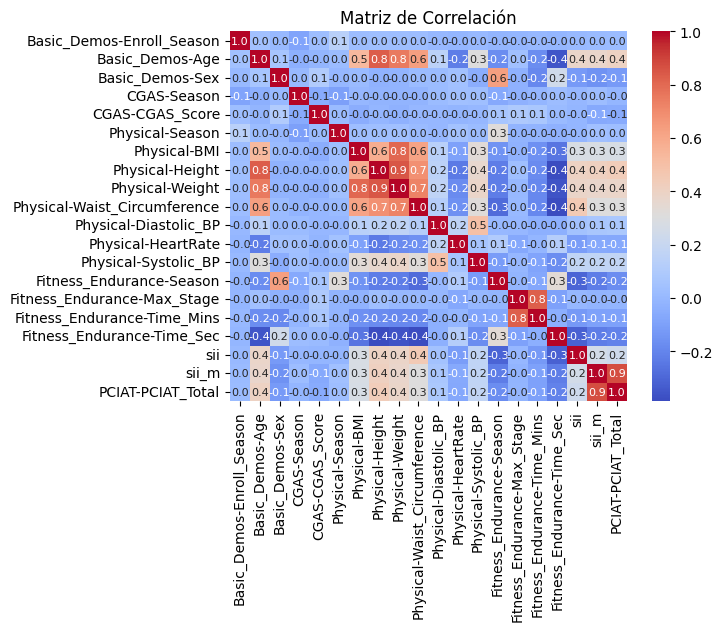

In [159]:
sns.heatmap(df[grupo_1].corr(), annot = True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 8})
plt.title('Matriz de Correlación')
plt.show()

#### Aqui vemos que las variables que estan más relacionadas con la variable objetivo son edad, peso, altura, indice de masa corporal, todos con un coeficiente de 4. Tambien se puede observar que todas tienen un relación positiva, si estas variables tienen un incremento del indice de deterioro de gravedad.

In [160]:
grupo_2 = ["FGC-Season","FGC-FGC_CU","FGC-FGC_CU_Zone","FGC-FGC_GSND","FGC-FGC_GSND_Zone","FGC-FGC_GSD","FGC-FGC_GSD_Zone","FGC-FGC_PU","FGC-FGC_PU_Zone","FGC-FGC_SRL",
           "FGC-FGC_SRL_Zone","FGC-FGC_SRR","FGC-FGC_SRR_Zone","FGC-FGC_TL","FGC-FGC_TL_Zone","sii","sii_m","PCIAT-PCIAT_Total"]

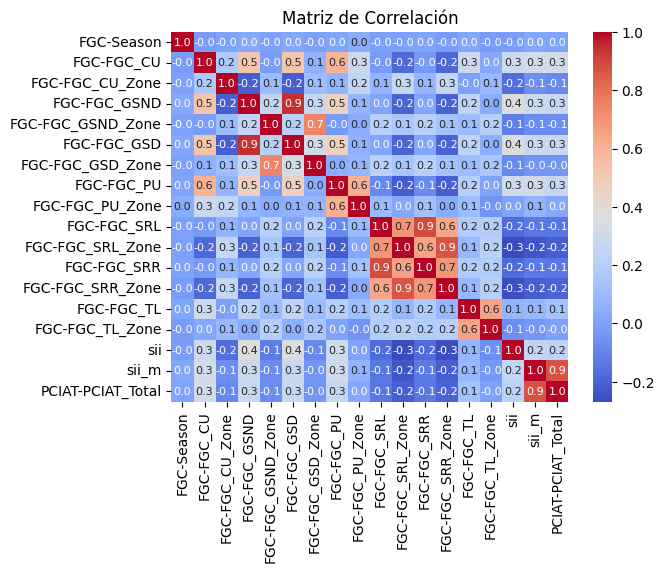

In [161]:
sns.heatmap(df[grupo_2].corr(), annot = True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 8})
plt.title('Matriz de Correlación')
plt.show()

#### En este segundo grupo fuerza de agarre de la mano dominante, mano no dominante y acurrucarse total las variables que tiene el coeficiene más alto con el indice de deterioro de gravedad.

In [162]:
grupo_3 = ["BIA-Season","BIA-BIA_Activity_Level_num","BIA-BIA_BMC","BIA-BIA_BMI","BIA-BIA_BMR","BIA-BIA_DEE","BIA-BIA_ECW","BIA-BIA_FFM","BIA-BIA_FFMI","BIA-BIA_FMI","BIA-BIA_Fat",
           "BIA-BIA_Frame_num","BIA-BIA_ICW","BIA-BIA_LDM","BIA-BIA_LST","BIA-BIA_SMM","BIA-BIA_TBW","sii","sii_m","PCIAT-PCIAT_Total"]

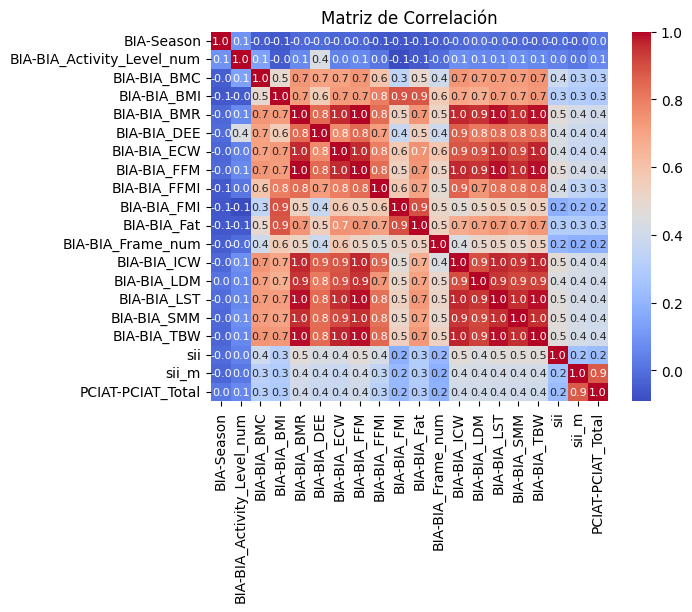

In [163]:
sns.heatmap(df[grupo_3].corr(), annot = True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 8})
plt.title('Matriz de Correlación')
plt.show()

#### Vemos en este grupo que las variables con el coeficinete de correlación mas alto son indice masa corporal, consumo diario energetico, total de agua en el cuerpo, todos alrededor de un 4.

In [164]:
grupo_4 = ["PCIAT-Season","PCIAT-PCIAT_01","PCIAT-PCIAT_02","PCIAT-PCIAT_03","PCIAT-PCIAT_04","PCIAT-PCIAT_05","PCIAT-PCIAT_06","PCIAT-PCIAT_07","PCIAT-PCIAT_08",
           "PCIAT-PCIAT_09","PCIAT-PCIAT_10","PCIAT-PCIAT_11","PCIAT-PCIAT_12","PCIAT-PCIAT_13","PCIAT-PCIAT_14","PCIAT-PCIAT_15","PCIAT-PCIAT_16","PCIAT-PCIAT_17",
           "PCIAT-PCIAT_18","PCIAT-PCIAT_19","PCIAT-PCIAT_20","sii","sii_m","PCIAT-PCIAT_Total"]

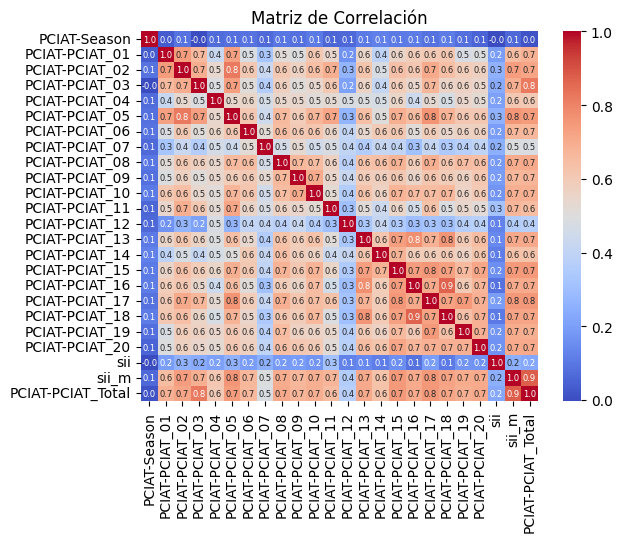

In [165]:
sns.heatmap(df[grupo_4].corr(), annot = True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 6})
plt.title('Matriz de Correlación')
plt.show()

#### En este grupo que las preguntas 2,5 y 11 de cuestionario son las que tienen el coeficiente mas alto alrededor de un 3.

In [166]:
grupo_5 = ["PAQ_A-Season","PAQ_A-PAQ_A_Total","PAQ_C-Season","PAQ_C-PAQ_C_Total","SDS-Season","SDS-SDS_Total_Raw","SDS-SDS_Total_T","PreInt_EduHx-Season","PreInt_EduHx-computerinternet_hoursday",
           "light","Estado_movimiento","Horario","Magnitud","quarter","weekday","tipo_actividad","Participo_Prueba","sii","sii_m","PCIAT-PCIAT_Total"]

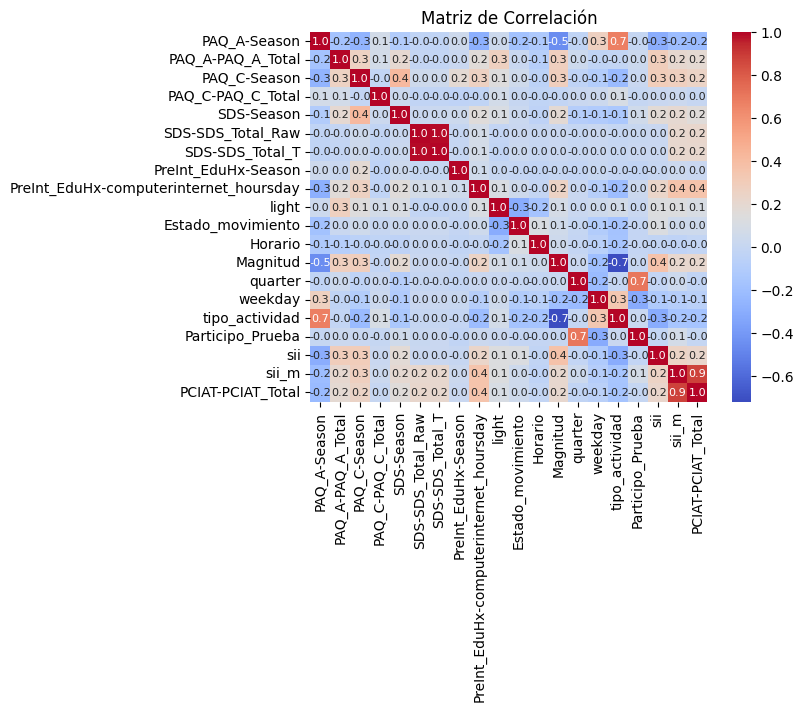

In [167]:
sns.heatmap(df[grupo_5].corr(), annot = True, cmap='coolwarm', fmt='.1f', annot_kws={"size": 8})
plt.title('Matriz de Correlación')
plt.show()

#### En este caso vemos que os dias de la semana, tipo_actividad, Magnitud son las que tienen el coeficiente más alto con relación a nuestra variables objetivo.

### Normalizacion de los datos 

In [168]:
df.head()

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,relative_date_PCIAT,weekday,quarter,Clusters,Participo_Prueba,sii_m,Magnitud,tipo_actividad,Estado_movimiento,Horario
0,0,0,5,0,3,51.0,0,16.877316,46.0,50.8,...,58.302728,4,0,0,0,2,0.078737,2,1,1
1,1,2,9,0,1,65.0,0,14.035590,48.0,46.0,...,58.302728,4,0,0,0,0,0.078737,2,1,1
2,3,3,9,0,0,71.0,2,18.292347,56.0,81.6,...,58.302728,4,2,0,1,1,0.078737,2,1,1
3,6,0,10,0,1,65.0,0,19.660760,55.0,84.6,...,58.302728,4,0,0,0,0,0.078737,2,1,1
4,11,0,11,0,2,66.0,1,16.871582,52.0,64.6,...,59.438255,4,0,0,0,0,0.139236,2,0,1


#### Tenemos pensado aplicar el algoritmo de Analisis de componentes pirncipales y para eso se requiero normalizar los datos. Ademas vemos que es necesario por la escala de los valores de las columnas del conjunto de datos.

In [169]:
# Estamos seleccionando las variabes predictoras y excluyendo la variable 
x_standarizar = df.drop(columns=['sii_m','id','time_of_day','PAQ_A-PAQ_A_Total','PCIAT-PCIAT_Total'])
Y = df["sii_m"]

In [170]:
#Inicializar el standarizador
scalar = StandardScaler()
X_estandarizado = scalar.fit_transform(x_standarizar)

### Analisis de importancia de variable con RandomForesRegressor 

In [171]:
# Creando la instancia de RandomForestRegressor 
rf = RandomForestClassifier()

In [172]:
# Se esta ajustando el modelo con los datos estandarizados
rf.fit(X = X_estandarizado, y = df["sii_m"])

RandomForestClassifier()

In [173]:
rf.feature_importances_

array([0.00218577, 0.00576127, 0.00064874, 0.00214817, 0.00543597,
       0.00192425, 0.0063036 , 0.00689965, 0.00713207, 0.00175343,
       0.00527153, 0.00562264, 0.00554724, 0.00164646, 0.00123703,
       0.00160955, 0.0029946 , 0.00203611, 0.00386687, 0.00081291,
       0.00757008, 0.00107904, 0.00402055, 0.0009659 , 0.00419844,
       0.00061969, 0.0037224 , 0.00050523, 0.00369256, 0.00079278,
       0.0036432 , 0.00068429, 0.00157378, 0.00200967, 0.0072391 ,
       0.00447027, 0.0074257 , 0.00692227, 0.00557127, 0.00636723,
       0.00524391, 0.00439538, 0.00447773, 0.00102013, 0.01003212,
       0.00767212, 0.00653148, 0.00814413, 0.00642337, 0.00149893,
       0.00163787, 0.005453  , 0.00293829, 0.03313991, 0.06987437,
       0.06485059, 0.01900165, 0.08337176, 0.02207736, 0.01232744,
       0.03056538, 0.02606541, 0.02434518, 0.03646798, 0.00463588,
       0.04379261, 0.02227598, 0.04610671, 0.03769681, 0.06098042,
       0.03376735, 0.03695426, 0.03013936, 0.00257102, 0.00564

In [174]:
# Seleccionando las columnas
columnas =  [x for x in df.columns if x not in ['sii','id','time_of_day','PAQ_A-PAQ_A_Total','PCIAT-PCIAT_Total']]


In [175]:
df_imp =  pd.DataFrame({"nombre": columnas, "importancia": rf.feature_importances_ })
df_imp

,nombre,importancia
0,Basic_Demos-Enroll_Season,0.002186
1,Basic_Demos-Age,0.005761
2,Basic_Demos-Sex,0.000649
3,CGAS-Season,0.002148
4,CGAS-CGAS_Score,0.005436
...,...,...
89,sii_m,0.001071
90,Magnitud,0.002592
91,tipo_actividad,0.000330
92,Estado_movimiento,0.000454


In [176]:
# Se estan ordenando los valores a traves de la columna importancia.
df_imp =  df_imp.sort_values("importancia", ascending = False)

In [177]:
# Se esta creando una columna que contenga el acumulando de varianza explicada.
df_imp["imp_acu"] = df_imp["importancia"].cumsum()


In [178]:
# Se esta filtrando el dataframe por la columna imp_cum para saber cuantas y cuales variables se requieren para explicar el 90% de la varianza.
df_imp[df_imp["imp_acu"]  < 0.90]

,nombre,importancia,imp_acu
57,PCIAT-PCIAT_05,0.083372,0.083372
54,PCIAT-PCIAT_02,0.069874,0.153246
55,PCIAT-PCIAT_03,0.064851,0.218097
69,PCIAT-PCIAT_17,0.060980,0.279077
67,PCIAT-PCIAT_15,0.046107,0.325184
65,PCIAT-PCIAT_13,0.043793,0.368976
68,PCIAT-PCIAT_16,0.037697,0.406673
71,PCIAT-PCIAT_19,0.036954,0.443628
63,PCIAT-PCIAT_11,0.036468,0.480095
70,PCIAT-PCIAT_18,0.033767,0.513863


In [179]:
# Este calculo nos permite saber cuantas variables se requiere para explicar el 90% de la varianza.
len(df_imp[df_imp["imp_acu"]  < 0.90])

45

#### Se realizó un análisis de importancias de las variables utilizar el algoritmo RandomForestClassifier() Indica cuánto contribuye cada característica al modelo para realizar predicciones precisas. Esto nos permitirá saber cuál de las variables o característica es más significativa para el modelo, ósea, para la varable sii_m. Aqui tenemos algunas observaciones: 
#### * 46 variables explican el 90% de las varianza del modelo o compoertamiento de la variable sii.
#### * La variable con mayor impacto la variable PCIAT-PCIAT_02.
#### * El 80% de la variaza se explica solo con 28 variables.


### Algoritmo de PCA

In [180]:
# Crea una instancia de PCA con el parameto n_components = 0.95 lo que indica seleccionaremos el numero de componenetes necesarios para explicar el 95% de la varianza de los datos.

pca = PCA(n_components = 0.95)

# Con este metodo de se calcula el numuero de componentes y se transforman los datos originales a la nueva representacion de los datos con menos dimensiones.
x_pca = pca.fit_transform(X_estandarizado)

In [181]:
# Se crea un Dataframen con los datos con su representacion.
df_pca = pd.DataFrame(x_pca)

In [182]:
x_pca.shape

(3960, 58)

In [183]:
# Con este metodo estamos viendo la explicacion de la varianza por cada uno de los componentes resultanta de aplicar el ajuste transformacio a los datos.

pca.explained_variance_ratio_.round(3)

array([0.26 , 0.093, 0.056, 0.035, 0.034, 0.028, 0.025, 0.022, 0.021,
       0.02 , 0.019, 0.018, 0.016, 0.015, 0.014, 0.014, 0.012, 0.012,
       0.011, 0.011, 0.01 , 0.01 , 0.01 , 0.009, 0.009, 0.009, 0.008,
       0.008, 0.007, 0.007, 0.007, 0.007, 0.007, 0.006, 0.006, 0.006,
       0.006, 0.006, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.004,
       0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.004, 0.003, 0.003,
       0.003, 0.003, 0.003, 0.003])

In [184]:
# Con este metodo veremos la suma acumulativa de la varianza explicada por cada componente. 
np.cumsum(pca.explained_variance_ratio_).round(3)

array([0.26 , 0.353, 0.408, 0.443, 0.477, 0.505, 0.53 , 0.552, 0.572,
       0.592, 0.611, 0.629, 0.645, 0.661, 0.675, 0.689, 0.701, 0.713,
       0.724, 0.735, 0.745, 0.755, 0.765, 0.774, 0.783, 0.791, 0.799,
       0.807, 0.815, 0.822, 0.829, 0.835, 0.842, 0.848, 0.854, 0.86 ,
       0.866, 0.872, 0.877, 0.882, 0.887, 0.892, 0.897, 0.902, 0.906,
       0.91 , 0.915, 0.919, 0.922, 0.926, 0.93 , 0.933, 0.937, 0.94 ,
       0.943, 0.946, 0.949, 0.952])

<Axes: xlabel='0', ylabel='1'>

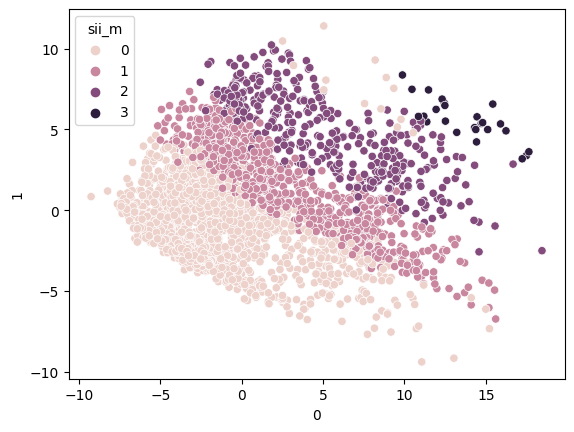

In [185]:
sns.scatterplot(x = df_pca[0], y = df_pca[1], hue = df["sii_m"])

#### En esta grafica vemos un patron claro de la cuatro categoria de la variable objetivo. Estos dos variables o componentes son los que explican por sepradado a mayor cantidad de varianza de los datos. Aqui podemos ver como el grupo numero 0 centra en el rango de -6 y 5 del componenete 0. Otro patron calros el grupo que tiene un rango de -4 hasta 9. De ese manera se ve el mismo comportamientos en los demas grupos.

### Division del conjunto de datos en pruebas y entrenamiento 

In [186]:
X_train, X_test, Y_train, Y_test = train_test_split(x_pca, Y, test_size=0.3,stratify=Y, random_state=42)

### Modelo de regresin logistica

In [187]:
modelo = LogisticRegression(max_iter=1000, multi_class='ovr')
parametros = {"C": [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08,0.09], 
              "class_weight":['balanced', None]}
model_GS = GridSearchCV(modelo, param_grid=parametros,
                         cv = 5, scoring='f1_macro')
model_GS.fit(X_train, Y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, multi_class='ovr'),
             param_grid={'C': [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08,
                               0.09],
                         'class_weight': ['balanced', None]},
             scoring='f1_macro')

In [188]:
print(model_GS.best_params_, "\nF1_marco: {}".format(round(model_GS.best_score_,2)))

{'C': 0.08, 'class_weight': 'balanced'} 
F1_marco: 0.67


#### Como se puede visualizar estos son los mejores parametros del modelo C': 0.07, 'class_weight': 'balanced y su puntuacion de f1_macro  0.65 que nos indica que tiene un rendimiento aceptable pero con margen de mejora. Esto se debe puede deberse a que el modelo no esta capturando todas las relaciones, lo intentaremos con otros mas robustos.

### Modelo de redes neuronales 

In [189]:
modelo = MLPClassifier()
parametros = {'solver': ['lbfgs'], 
              'max_iter': [100,200,300,500,700,800,1000], # Iteraciones máximas en cada red
              'alpha': 10.0 ** -np.arange(1, 10), # Parámetro de reguzlarización L2 para evitar sobreajuste
              'hidden_layer_sizes':[(100,), (50,50), (64,32)], # Número de neuronas en cada capa
              'random_state':[0]}

In [190]:
model_RN = GridSearchCV(modelo, param_grid=parametros, cv = 3, 
                         scoring='f1_macro', n_jobs=-1, verbose=10)
model_RN.fit(X_train, Y_train)

Fitting 3 folds for each of 189 candidates, totalling 567 fits


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:541: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html



GridSearchCV(cv=3, estimator=MLPClassifier(), n_jobs=-1,
             param_grid={'alpha': array([1.e-01, 1.e-02, 1.e-03, 1.e-04, 1.e-05, 1.e-06, 1.e-07, 1.e-08,
       1.e-09]),
                         'hidden_layer_sizes': [(100,), (50, 50), (64, 32)],
                         'max_iter': [100, 200, 300, 500, 700, 800, 1000],
                         'random_state': [0], 'solver': ['lbfgs']},
             scoring='f1_macro', verbose=10)

In [191]:
print(model_RN.best_params_, "\nf1_macro: {}".format(round(model_RN.best_score_,2)))

{'alpha': 0.1, 'hidden_layer_sizes': (64, 32), 'max_iter': 100, 'random_state': 0, 'solver': 'lbfgs'} 
f1_macro: 0.86


#### Como podemos ver el valor arrojado por la metrica f1_micro fue 0.21 mayor que el modelo de regresion logistica. Esto tambien nos dice que este modelo de red neuronal capturo relaciones mas profundas entre las variables. El modelo tiene dos capas profundas la primera de 64 neuronas y la segunda de 32 con una iteracion 200 epoc. Tambien vemos que el parametro de regularizacion L2 es 0.1 es moderado, esto nos ayuda con el sobreajuste del modelo con los datos de entreamiento.

### Modelo de Random forest 

In [192]:
modelo_2 = RandomForestClassifier()
params = {"n_estimators" : [10, 50, 100, 200],
         "max_depth" : [5, 7, 9],
         "max_features": [10, "sqrt"]}

In [193]:
model_RF = GridSearchCV(modelo_2, params, cv=3, n_jobs=-1)
model_RF.fit(X_train, Y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [5, 7, 9], 'max_features': [10, 'sqrt'],
                         'n_estimators': [10, 50, 100, 200]})

In [194]:
print(model_RF.best_params_, "\nf1_macro: {}".format(round(model_RF.best_score_,2)))

{'max_depth': 9, 'max_features': 10, 'n_estimators': 200} 
f1_macro: 0.9


#### Dado estos resultados, vemos que hasta el momento modelo de Random forest tiene la mejor puntuacion de la metrica f1_macro con 0.91, los que nos indica que de los tres modelos analizados es mejor para prediciendo las clasificaciones. Tambien nos dice que tiene una buena puntuacion con las metricas precision y recall, como sabemos las primera castiga muchos los falsos positivios y la otra os falsos negativos. 

#### Modelo XGBoots XGBClassifier 

In [195]:
# Definir el modelo base
xgb = XGBClassifier(
    objective='multi:softprob',  # multiclase con probabilidades
    num_class=4,
    use_label_encoder=False,
    eval_metric='mlogloss'       # log-loss multiclase
)

In [196]:
# Definir espacio de búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

In [197]:
# Ejecutar GridSearchCV
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=3,            # validación cruzada
    verbose=1,
    n_jobs=-1        # usa todos los núcleos disponibles
)

grid.fit(X_train, Y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=4,
                                     num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [50, 100], 'subsample': [0.8, 1.0]},
             scoring='f1_macro', verbose=1)

In [198]:
print(grid.best_params_, "\nf1_macro: {}".format(round(grid.best_score_,2)))

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0} 
f1_macro: 0.89


#### Dado estos resultados, vemos que el modelo de Random forest tiene la mejor puntuacion de la metrica f1_macro con 0.91, a pesar de que no por muchas diferencia, ya que el XGBClassifier arrojo un 0.90. Esto nos indica que de los cuatro modelos analizados es mejor para prediciendo las clasificaciones. Tambien nos dice que tiene una buena puntuacion con las metricas precision y recall, como sabemos las primera castiga muchos los falsos positivios y la otra os falsos negativos. 

#### Dada esta puntuacion el modelo que seleccionaremos el modelo de Random Foreste Classifier.

### Predicciones y otras metricas

In [199]:
# Crearemos otro objeto con los mejores paramentros 
Op_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=9,
    max_features=10,
    class_weight='balanced',        # o 'balanced_subsample'
    random_state=42
)

In [200]:
# Entrenamiento del modelo 
Op_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=9, max_features=10,
                       n_estimators=200, random_state=42)

In [201]:
y_predict = Op_model.predict(X_test)
y_predict

array([0, 1, 1, ..., 1, 1, 0])

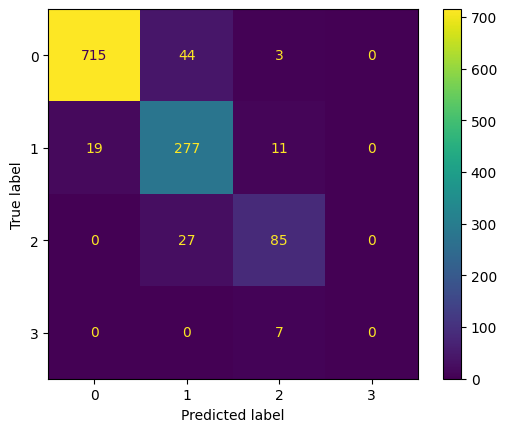

In [202]:
cm = confusion_matrix(Y_test, y_predict)

ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [203]:
accuracy = accuracy_score(Y_test, y_predict)
print("Accuracy:", accuracy)

Accuracy: 0.9065656565656566


 #### Como se puede ver la exactitud del modelo fue de 91%,  mide la proporción de observaciones clasificadas correctamente de entre todas las observaciones, lo que significa que el 91% de las observaciones se clasificaron correctamente.

In [204]:
precision = precision_score(Y_test, y_predict, average = 'weighted')
print("Precision:", precision)

Precision: 0.90610392899253


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



#### Como podemos observar la metrica precision arrojo un valor de 91%, la cual mide la  proporción de verdaderos positivos (observaciones positivas correctamente clasificadas) de todas las obervaciones clasificadas como positivas, lo que significa que el 91% las observaciones positivas se clasificaron correctamente.

In [205]:
recall = recall_score(Y_test, y_predict,average = 'weighted')
print("Recall:", recall)

Recall: 0.9065656565656566


#### Como podemos observar la metrica Recall,, que mide la proporción de verdaderos positivos de todos los casos positivos reales En este caso, el modelo tiene un recuerdo de %,91 lo que significa que sólo clasificó correctamente el 91% de los casos positivos reales.

In [206]:
print(classification_report(y_predict,Y_test))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       734
           1       0.90      0.80      0.85       348
           2       0.76      0.80      0.78       106
           3       0.00      0.00      0.00         0

    accuracy                           0.91      1188
   macro avg       0.65      0.64      0.65      1188
weighted avg       0.91      0.91      0.91      1188



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning:

Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.



#### A pesar de la buneas metricas que tiene el modelo en precision, recall y f1_score, vemos que la clase 3, que corresponden a personas adictivas no tienne muestras para predicir su clasificación. Esto se debe al desbalance que tiene la distribución de los valores de la columna sii_m, la cual es nuestra variable objetivo. Se intento balancer con el parametro class_weight='balanced' cuando creamos la instancia, sin embargo no tuvo el efecto deseado. 

#### Dada esta situación tenemos que la opción del modelo XGBClasifier con f1_macro 0.90 que es un balance entre la metrica recall y precision y nos dice que tiene un buen rendimiento de manera global. 

### Predicciones y otras metricas con XGBootClassifier 

In [207]:
# Se estan creaando datos sintenticos con el metodo SMOTE. Estamos haciendo esto para balance los valores de la columna objetivo que tiene muy poco valores en la columana support cuando aplicamos las metrcias.
# El metodo, SMOTE nos ayudara a interpolar nuevos puntos entre cada muestra minoritaria y sus vecinos más cercanos.

smote = SMOTE(
    sampling_strategy={3: 80},   # Genera hasta 50 ejemplos sintéticos de la clase 3
    k_neighbors=2,               # Vecinos para interpolar (elige < soporte real)
    random_state=42
)
X_res, Y_res = smote.fit_resample(X_train, Y_train)

In [208]:
xgb_model = XGBClassifier(
    objective='multi:softprob',       # Para clasificación multiclase con probabilidades
    eval_metric='mlogloss',           # Métrica estándar para multiclase (también puedes probar 'mlogloss' y 'merror')
    n_estimators=100,                 # Confirmado por GridCV
    max_depth=3,                      # Confirmado por GridCV
    subsample=0.8,                    # Confirmado por GridCV
    colsample_bytree=0.8,             # Añadido: Mejora generalización reduciendo correlación entre árboles
    learning_rate=0.1,                # Confirmado por GridCV
    gamma=0.1,                          # Regularización mínima por ahora (puedes tunearlo luego)
    reg_alpha=0.1,                    # L1 regularization (previene overfitting)
    reg_lambda=1.0,                   # L2 regularization (estabiliza el modelo)
    use_label_encoder=False,          # Para evitar warnings en versiones modernas de XGBoost
    verbosity=1,                      # Muestra advertencias y errores mínimos
    random_state=42,                  # Reproducibilidad
    n_jobs=-1                         # Uso completo de núcleos para paralelismo
)

In [209]:
xgb_model.fit(X_res, Y_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, objective='multi:softprob', ...)

In [210]:
y_predict1 = xgb_model.predict(X_test)
y_predict1

array([0, 0, 1, ..., 1, 2, 0])

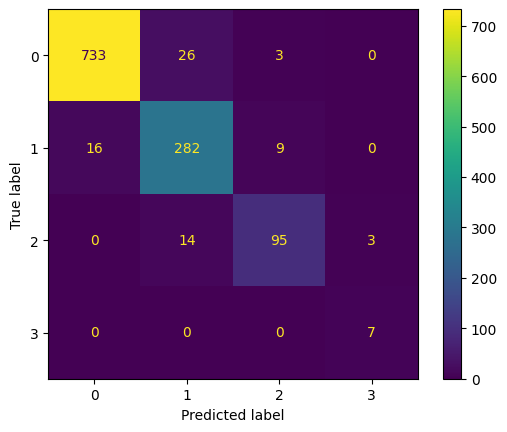

In [211]:
cm1 = confusion_matrix(Y_test, y_predict1)

ConfusionMatrixDisplay(confusion_matrix=cm1).plot();

In [212]:
accuracy = accuracy_score(Y_test, y_predict1)
print("Accuracy:", accuracy)

Accuracy: 0.9402356902356902


#### Como se puede ver la exactitud del modelo fue de 94%,  mide la proporción de observaciones clasificadas correctamente de entre todas las observaciones, lo que significa que el 94% de las observaciones se clasificaron correctamente.

In [213]:
precision = precision_score(Y_test, y_predict1, average = 'weighted')
print("Precision:", precision)

Precision: 0.9418559787617081


#### Como podemos observar la metrica precision arrojo un valor de 94%, la cual mide la  proporción de verdaderos positivos (observaciones positivas correctamente clasificadas) de todas las obervaciones clasificadas como positivas, lo que significa que el 94% las observaciones positivas se clasificaron correctamente.

In [214]:
recall = recall_score(Y_test, y_predict1,average = 'weighted')
print("Recall:", recall)

Recall: 0.9402356902356902


#### Como podemos observar la metrica Recall,que mide la proporción de verdaderos positivos de todos los casos positivos reales En este caso, el modelo tiene un recuerdo de 94%, lo que significa que sólo clasificó correctamente el 94% de los casos positivos reales.

In [215]:
print(classification_report(y_predict1,Y_test))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       749
           1       0.92      0.88      0.90       322
           2       0.85      0.89      0.87       107
           3       1.00      0.70      0.82        10

    accuracy                           0.94      1188
   macro avg       0.93      0.86      0.89      1188
weighted avg       0.94      0.94      0.94      1188



#### Tras ir probando varios valores del parametro sampling_strategy, correspondiente al metodo SMOTE, obtuvimos muy buenos resultados al fijar la cantidad de datos sinteticos en 80.
#### Las metricas precision, recall y f1_score mejoraron significativamente.tambien podemos ver que a nivel general la precision muy buena, de cada clase predicha, en promedio, de cada 10 predicciones, 9 sera correctas. En cuanto a la parte de recall, que se encargada de como este modelo identifica los casos reales, a nivel general y en promedio, de cada 10 casos reales solamente se le escapa 1.
#### En en el caso de nosotros es de suma importancia que las predicciones sean confiables y identifique o reconozca  los casos reales.



In [216]:
n_clases = 4

# Paso 1: Binarizar las etiquetas verdaderas
Y_test_bin = label_binarize(Y_test, classes=[0, 1, 2, 3])
# Y_test_bin tendrá forma [n_muestras, 4]

# Paso 2: Obtener las probabilidades por clase
y_t_pred_pro = xgb_model.predict_proba(X_test)
# y_t_pred_pro debe tener forma [n_muestras, 4]

# Inicializar diccionarios para guardar los resultados
fpr = dict()
tpr = dict()
roc_auc = dict()

# Paso 3: Para cada clase, calcula la curva ROC (OvR)
for i in range(n_clases):
    y_true_bin = Y_test_bin[:, i]              # 1 si pertenece a la clase i, 0 si no
    y_score = y_t_pred_pro[:, i]               # Probabilidad asignada a la clase i
    fpr[i], tpr[i], _ = roc_curve(y_true_bin, y_score)
    roc_auc[i] = auc(fpr[i], tpr[i])

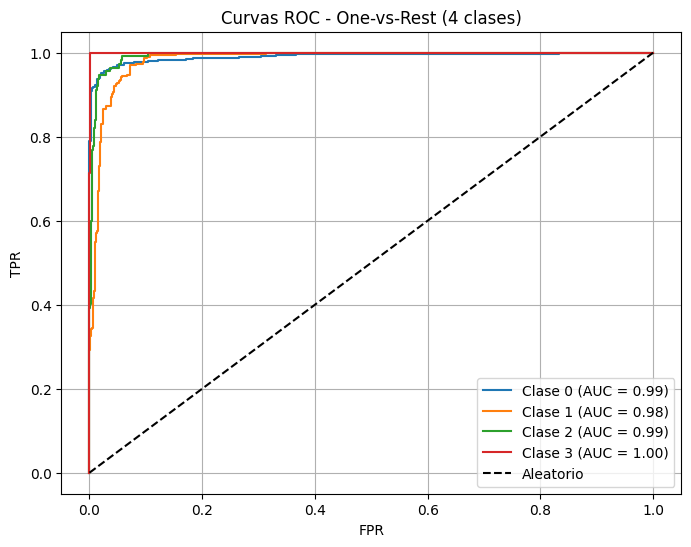

In [217]:
plt.figure(figsize=(8, 6))
for i in range(n_clases):
    plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curvas ROC - One-vs-Rest (4 clases)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### Estos graficos son representan la curva ROC los cuales se utilizar para caso binarios y saber que tanto bien clasifica un modelo binario. En este caso aplicamos para un modelo multiclase utilizando la estrategia OvR. Este metodo consiste en comparar un clase con el resto, la clase elegida toma el valor de tasa de verdaderos positivos y el resto de tasa de falsos positivos. Quise utilizar esta estrategia ya que queria ver, de manera grafica, que tambien discriminaba las clases, o para ser mas especifico que tambien clasificaba o diferencia entre las clases.

#### A nivel general vemos que el modelos tiene una muy precisión al momentos de diferenciar y clasificar entre las clases. Vemos a modos de ejemplo, que el modelo, en nuestro caso, diferencia muy aquellos niños y adolecente tiene uso problematico del internet y aquellos que no. De igual manera que clasifica muy aquellos que tienen una conducta media o moderada, los cuales pueden corregirse antes de que asuman un estatus de severo o su salud se vea afectada.

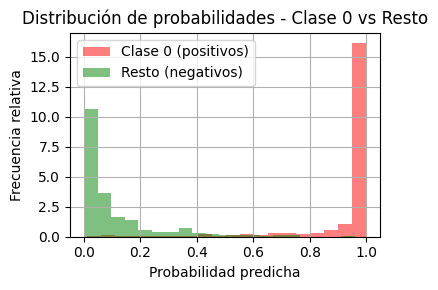

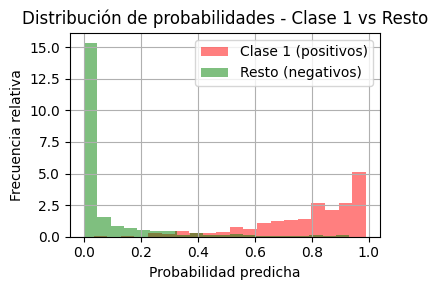

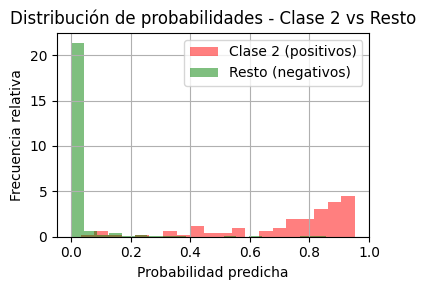

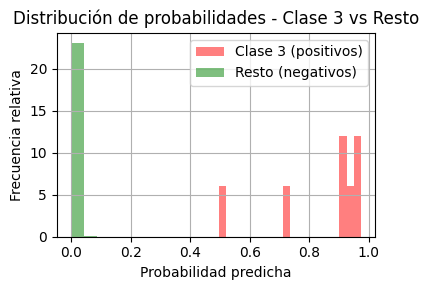

In [218]:
representar_histogramas_ovr(Y_test, y_t_pred_pro, figsize=(4, 3))

#### En estos histogramas podemos seguir confirmando la calidad del modelo a la hora de realizar buenas clasificaciones o discriminaciones entre clases. A nivel general vemos que el modelo separa muy bien las clases. En el caso de la clase 3, en nuestro caso de estudio, niños o adolecente que tiene una conducta de estatus grave con el uso problematico del internet, lo discrimina muy bien. Esto es bien importante para este caso, ya que es crucial de predecir una clasificación de este tipo.